In [1]:
import warnings
warnings.filterwarnings("ignore")

from math import erf, sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    make_scorer
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 16
})

RANDOM_STATE = 42

USAR_DATASET_EXTERNO = False
RUTA_CSV = "credit_default.csv"
COLUMNA_OBJETIVO = "default_90d"

N_REGISTROS_SINTETICOS = 8000

TEST_SIZE = 0.20
DEV_SIZE_SOBRE_TRAIN = 0.25

RECALL_MINIMO_SMART = 0.70
PRECISION_MINIMA_SMART = 0.40
ROC_AUC_MINIMO_SMART = 0.80

EJECUTAR_VALIDACION_CRUZADA = True
N_SPLITS_CV = 5

CALCULAR_INTERVALOS_BOOTSTRAP = True
N_BOOTSTRAP = 250

CALCULAR_IMPORTANCIA_PERMUTACION = True
MUESTRA_IMPORTANCIA = 1500
N_REPEATS_IMPORTANCIA = 5

MOSTRAR_GRAFICAS = True
EXPORTAR_RESULTADOS = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

PERDIDA_MEDIA_DEFAULT = 16000
REDUCCION_PERDIDA_ACCION = 0.35
COSTO_REVISION = 350
COSTO_OPORTUNIDAD_BUEN_CLIENTE = 450

BENEFICIO_TP = PERDIDA_MEDIA_DEFAULT * REDUCCION_PERDIDA_ACCION - COSTO_REVISION
COSTO_FP = COSTO_REVISION + COSTO_OPORTUNIDAD_BUEN_CLIENTE

OBJETIVO_SMART = f"""
OBJETIVO SMART
---------------
Problema financiero:
Clasificar solicitudes de crédito según su probabilidad de incumplimiento a 90 días.

Objetivo:
Seleccionar, validar y justificar un modelo de aprendizaje automático que identifique clientes con alto riesgo de default,
comparando 4 modelos supervisados contra un baseline de reglas financieras.

Criterios SMART:
1. Específico: detectar clientes con riesgo de default_90d = 1.
2. Medible: evaluar Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Brier Score, MCC y utilidad incremental.
3. Alcanzable: usar variables financieras simuladas realistas o un CSV externo.
4. Relevante: reducir pérdida esperada mediante revisión o ajuste de condiciones para clientes de alto riesgo.
5. Temporal: validar el desempeño en un conjunto test separado, simulando originación crediticia.

Criterio operativo:
- Recall mínimo deseado: {RECALL_MINIMO_SMART:.0%}
- Precision mínima deseada: {PRECISION_MINIMA_SMART:.0%}
- ROC-AUC mínimo deseado: {ROC_AUC_MINIMO_SMART:.2f}
- El modelo seleccionado debe mejorar la utilidad incremental por cada 1,000 solicitudes frente al baseline.
"""

print(OBJETIVO_SMART)


def generar_dataset_financiero(n=8000, random_state=42):
    rng = np.random.default_rng(random_state)

    edad = np.clip(rng.normal(41, 11, n).round(), 21, 72).astype(int)

    ingresos_anuales = np.clip(
        rng.lognormal(mean=np.log(38000), sigma=0.55, size=n),
        8000,
        210000
    )

    antiguedad_laboral_meses = np.clip(
        rng.gamma(shape=4.0, scale=18.0, size=n),
        1,
        360
    )

    score_buro = np.clip(
        rng.normal(675, 80, n)
        + (np.log(ingresos_anuales) - np.log(38000)) * 35
        + (antiguedad_laboral_meses / 120) * 8,
        300,
        850
    )

    uso_linea_credito = np.clip(
        rng.beta(2.1, 3.5, n) + (650 - score_buro) / 1000,
        0.02,
        0.98
    )

    ratio_deuda_ingreso = np.clip(
        rng.normal(0.34, 0.14, n)
        + uso_linea_credito * 0.18
        + (650 - score_buro) / 1600,
        0.03,
        0.92
    )

    atrasos_12m = rng.poisson(
        np.clip(
            0.25 + 1.6 * uso_linea_credito + (620 - score_buro) / 180,
            0.02,
            4.0
        )
    ).astype(int)

    monto_credito = np.clip(
        rng.lognormal(mean=np.log(19000), sigma=0.65, size=n),
        1000,
        130000
    )

    ratio_credito_ingreso = np.clip(monto_credito / ingresos_anuales, 0.02, 4.0)

    tasa_interes = np.clip(
        0.085
        + (700 - score_buro) / 2400
        + ratio_deuda_ingreso * 0.045
        + uso_linea_credito * 0.035
        + rng.normal(0, 0.006, n),
        0.055,
        0.295
    )

    plazo_meses = rng.choice(
        [24, 36, 48, 60, 72],
        size=n,
        p=[0.08, 0.28, 0.33, 0.23, 0.08]
    )

    cuentas_abiertas = np.clip(
        rng.poisson(5 + ingresos_anuales / 35000),
        1,
        22
    )

    prior_default = rng.binomial(
        1,
        np.clip(0.03 + (640 - score_buro) / 1000 + uso_linea_credito * 0.05, 0.01, 0.22),
        n
    )

    desempleo_macro = np.clip(rng.normal(0.045, 0.012, n), 0.025, 0.095)

    tipo_empleo = rng.choice(
        ["Asalariado", "Independiente", "Temporal", "Pensionado"],
        size=n,
        p=[0.62, 0.22, 0.10, 0.06]
    )

    destino_credito = rng.choice(
        ["Auto", "Personal", "Consolidacion deuda", "Negocio", "Educacion"],
        size=n,
        p=[0.32, 0.28, 0.20, 0.13, 0.07]
    )

    canal = rng.choice(
        ["Digital", "Sucursal", "Broker", "Telemarketing"],
        size=n,
        p=[0.38, 0.34, 0.18, 0.10]
    )

    logit_default = (
        -2.7
        + 1.15 * ((ratio_deuda_ingreso - 0.34) / 0.16)
        + 0.90 * ((uso_linea_credito - 0.45) / 0.25)
        + 0.22 * atrasos_12m
        - 1.25 * ((score_buro - 660) / 100)
        + 0.55 * ((ratio_credito_ingreso - 0.55) / 0.45)
        + 1.10 * prior_default
        + 0.35 * (plazo_meses >= 60).astype(int)
        + 0.32 * (destino_credito == "Consolidacion deuda").astype(int)
        + 0.28 * (tipo_empleo == "Temporal").astype(int)
        + 2.00 * (desempleo_macro - 0.045)
        + rng.normal(0, 0.60, n)
    )

    prob_default = 1 / (1 + np.exp(-logit_default))
    default_90d = rng.binomial(1, prob_default)

    df = pd.DataFrame({
        "edad": edad,
        "ingresos_anuales": ingresos_anuales.round(2),
        "antiguedad_laboral_meses": antiguedad_laboral_meses.round(1),
        "score_buro": score_buro.round(0),
        "ratio_deuda_ingreso": ratio_deuda_ingreso.round(4),
        "uso_linea_credito": uso_linea_credito.round(4),
        "atrasos_12m": atrasos_12m,
        "monto_credito": monto_credito.round(2),
        "ratio_credito_ingreso": ratio_credito_ingreso.round(4),
        "tasa_interes": tasa_interes.round(4),
        "plazo_meses": plazo_meses,
        "cuentas_abiertas": cuentas_abiertas,
        "prior_default": prior_default,
        "desempleo_macro": desempleo_macro.round(4),
        "tipo_empleo": tipo_empleo,
        "destino_credito": destino_credito,
        "canal": canal,
        "prob_default_real_sintetica": prob_default.round(4),
        "default_90d": default_90d
    })

    return df


OBJETIVO SMART
---------------
Problema financiero:
Clasificar solicitudes de crédito según su probabilidad de incumplimiento a 90 días.

Objetivo:
Seleccionar, validar y justificar un modelo de aprendizaje automático que identifique clientes con alto riesgo de default,
comparando 4 modelos supervisados contra un baseline de reglas financieras.

Criterios SMART:
1. Específico: detectar clientes con riesgo de default_90d = 1.
2. Medible: evaluar Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Brier Score, MCC y utilidad incremental.
3. Alcanzable: usar variables financieras simuladas realistas o un CSV externo.
4. Relevante: reducir pérdida esperada mediante revisión o ajuste de condiciones para clientes de alto riesgo.
5. Temporal: validar el desempeño en un conjunto test separado, simulando originación crediticia.

Criterio operativo:
- Recall mínimo deseado: 70%
- Precision mínima deseada: 40%
- ROC-AUC mínimo deseado: 0.80
- El modelo seleccionado debe mejorar la utilidad inc

In [2]:
def imprimir_titulo(texto):
    print("\n" + "=" * 100)
    print(texto)
    print("=" * 100)


def crear_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def normal_cdf(x):
    return (1 + erf(x / sqrt(2))) / 2


def prueba_z_dos_proporciones(x1, n1, x2, n2):
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    p_pool = (x1 + x2) / (n1 + n2)
    se = sqrt(p_pool * (1 - p_pool) * ((1 / n1) + (1 / n2)))

    if se == 0:
        return 0.0, 1.0

    z = ((x1 / n1) - (x2 / n2)) / se
    p_value = 2 * (1 - normal_cdf(abs(z)))
    return z, p_value


def safe_div(a, b):
    return 0.0 if b == 0 else a / b


def calcular_utilidad_incremental(tp, fp, fn, tn):
    return tp * BENEFICIO_TP - fp * COSTO_FP


def convertir_target_binario(y):
    if pd.api.types.is_numeric_dtype(y):
        valores = sorted(pd.Series(y).dropna().unique())
        if len(valores) != 2:
            raise ValueError("La columna objetivo debe tener exactamente 2 clases.")
        if set(valores).issubset({0, 1}):
            return y.astype(int)

        mapa = {valores[0]: 0, valores[1]: 1}
        return y.map(mapa).astype(int)

    y_str = y.astype(str).str.strip().str.lower()
    mapa_texto = {
        "1": 1,
        "si": 1,
        "sí": 1,
        "yes": 1,
        "true": 1,
        "default": 1,
        "malo": 1,
        "bad": 1,
        "incumple": 1,
        "0": 0,
        "no": 0,
        "false": 0,
        "good": 0,
        "bueno": 0,
        "no default": 0,
        "cumple": 0,
    }

    y_map = y_str.map(mapa_texto)

    if y_map.isna().any():
        valores = sorted(y_str.dropna().unique())
        if len(valores) != 2:
            raise ValueError("No se pudo convertir la columna objetivo a binaria 0/1.")
        mapa = {valores[0]: 0, valores[1]: 1}
        y_map = y_str.map(mapa)

    return y_map.astype(int)


def cargar_datos():
    if USAR_DATASET_EXTERNO:
        df = pd.read_csv(RUTA_CSV)

        if COLUMNA_OBJETIVO not in df.columns:
            raise ValueError(f"No existe la columna objetivo: {COLUMNA_OBJETIVO}")

        df[COLUMNA_OBJETIVO] = convertir_target_binario(df[COLUMNA_OBJETIVO])
        return df, COLUMNA_OBJETIVO

    df = generar_dataset_financiero(
        n=N_REGISTROS_SINTETICOS,
        random_state=RANDOM_STATE
    )
    return df, "default_90d"


def construir_preprocesador(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", crear_one_hot_encoder())
    ])

    transformers = []

    if numeric_features:
        transformers.append(("num", numeric_transformer, numeric_features))

    if categorical_features:
        transformers.append(("cat", categorical_transformer, categorical_features))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    return preprocessor, numeric_features, categorical_features


def obtener_probabilidad_default(modelo, X):
    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X)
        clases = list(modelo.classes_)
        idx = clases.index(1) if 1 in clases else 1
        return proba[:, idx]

    if hasattr(modelo, "decision_function"):
        score = modelo.decision_function(X)
        return 1 / (1 + np.exp(-score))

    pred = modelo.predict(X)
    return np.asarray(pred, dtype=float)


def evaluar_predicciones(y_true, y_score, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = np.asarray(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    especificidad = safe_div(tn, tn + fp)

    utilidad = calcular_utilidad_incremental(tp, fp, fn, tn)

    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except ValueError:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_score)
    except ValueError:
        pr_auc = np.nan

    try:
        brier = brier_score_loss(y_true, y_score)
    except ValueError:
        brier = np.nan

    if len(np.unique(y_pred)) > 1:
        mcc = matthews_corrcoef(y_true, y_pred)
    else:
        mcc = 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "especificidad": especificidad,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": mcc,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier": brier,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "utilidad_incremental_total": utilidad,
        "utilidad_incremental_1000": utilidad / len(y_true) * 1000,
        "tasa_alertas": float(np.mean(y_pred))
    }


def optimizar_umbral(
    y_true,
    y_score,
    metrica_objetivo="utilidad_incremental_1000",
    recall_minimo=None,
    precision_minima=None
):
    filas = []

    for umbral in np.linspace(0.01, 0.99, 99):
        y_pred = (np.asarray(y_score) >= umbral).astype(int)
        fila = evaluar_predicciones(y_true, y_score, y_pred)
        fila["umbral"] = float(umbral)
        filas.append(fila)

    df_umbral = pd.DataFrame(filas)

    candidatos = df_umbral.copy()

    if recall_minimo is not None:
        candidatos = candidatos[candidatos["recall"] >= recall_minimo]

    if precision_minima is not None:
        candidatos = candidatos[candidatos["precision"] >= precision_minima]

    if candidatos.empty:
        candidatos = df_umbral.copy()

    idx = candidatos[metrica_objetivo].idxmax()
    mejor_umbral = float(df_umbral.loc[idx, "umbral"])

    return mejor_umbral, df_umbral


def regla_baseline_financiera(X, tasa_base=0.20):
    requeridas = {
        "score_buro",
        "ratio_deuda_ingreso",
        "uso_linea_credito",
        "atrasos_12m",
        "prior_default",
        "ratio_credito_ingreso"
    }

    if not requeridas.issubset(set(X.columns)):
        return np.repeat(float(tasa_base), len(X))

    puntos = np.zeros(len(X), dtype=float)

    puntos += np.where(
        X["score_buro"].values < 620,
        3.0,
        np.where(X["score_buro"].values < 660, 1.5, 0.0)
    )

    puntos += np.where(
        X["ratio_deuda_ingreso"].values > 0.55,
        2.0,
        np.where(X["ratio_deuda_ingreso"].values > 0.45, 1.0, 0.0)
    )

    puntos += np.where(
        X["uso_linea_credito"].values > 0.80,
        2.0,
        np.where(X["uso_linea_credito"].values > 0.65, 1.0, 0.0)
    )

    puntos += np.where(
        X["atrasos_12m"].values >= 2,
        2.0,
        np.where(X["atrasos_12m"].values == 1, 1.0, 0.0)
    )

    puntos += np.where(X["prior_default"].values == 1, 1.5, 0.0)
    puntos += np.where(X["ratio_credito_ingreso"].values > 1.0, 1.0, 0.0)

    score_regla = np.clip(puntos / 11.5, 0, 1)
    return score_regla


def calcular_ganancia_lift(y_true, y_score, n_bins=10):
    rank = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "score": np.asarray(y_score, dtype=float)
    })

    rank = rank.sort_values("score", ascending=False).reset_index(drop=True)
    rank["decil"] = np.ceil((np.arange(len(rank)) + 1) / len(rank) * n_bins).astype(int)

    resumen = rank.groupby("decil").agg(
        casos=("y", "size"),
        defaults=("y", "sum"),
        score_min=("score", "min"),
        score_max=("score", "max")
    )

    resumen["casos_acum"] = resumen["casos"].cumsum()
    resumen["defaults_acum"] = resumen["defaults"].cumsum()

    total_defaults = rank["y"].sum()
    tasa_base = rank["y"].mean()

    resumen["porc_poblacion_acum"] = resumen["casos_acum"] / len(rank)
    resumen["captura_defaults_acum"] = resumen["defaults_acum"] / total_defaults if total_defaults > 0 else 0
    resumen["bad_rate_decil"] = resumen["defaults"] / resumen["casos"]
    resumen["lift_decil"] = resumen["bad_rate_decil"] / tasa_base if tasa_base > 0 else 0

    return resumen.reset_index()


def bootstrap_ci(y_true, y_score, umbral, n_bootstrap=250, random_state=42):
    rng = np.random.default_rng(random_state)
    y_arr = np.asarray(y_true).astype(int)
    p_arr = np.asarray(y_score, dtype=float)
    n = len(y_arr)

    metricas = [
        "precision",
        "recall",
        "f1",
        "f2",
        "roc_auc",
        "pr_auc",
        "brier",
        "utilidad_incremental_1000",
        "tasa_alertas"
    ]

    registros = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        if len(np.unique(y_arr[idx])) < 2:
            continue

        y_b = y_arr[idx]
        p_b = p_arr[idx]
        pred_b = (p_b >= umbral).astype(int)

        met = evaluar_predicciones(y_b, p_b, pred_b)
        registros.append({m: met[m] for m in metricas})

    df_boot = pd.DataFrame(registros)

    ci = df_boot.quantile([0.025, 0.50, 0.975]).T
    ci.columns = ["p2.5", "mediana", "p97.5"]

    return ci

In [3]:
imprimir_titulo("CARGA DATOS")

df, target_col = cargar_datos()

columnas_excluir = [target_col]
if "prob_default_real_sintetica" in df.columns:
    columnas_excluir.append("prob_default_real_sintetica")

X = df.drop(columns=columnas_excluir)
y = convertir_target_binario(df[target_col])

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas predictoras: {X.shape[1]:,}")
print(f"Tasa de default: {y.mean():.2%}")
display(df.head())

preprocesador, numeric_features, categorical_features = construir_preprocesador(X)

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)


X_entrenamiento_total, X_test, y_entrenamiento_total, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_entrenamiento_total,
    y_entrenamiento_total,
    test_size=DEV_SIZE_SOBRE_TRAIN,
    random_state=RANDOM_STATE,
    stratify=y_entrenamiento_total
)

imprimir_titulo("PARTICIÓN DE DATOS")

print(f"Train: {X_train.shape[0]:,} registros | Default rate: {y_train.mean():.2%}")
print(f"Dev:   {X_dev.shape[0]:,} registros | Default rate: {y_dev.mean():.2%}")
print(f"Test:  {X_test.shape[0]:,} registros | Default rate: {y_test.mean():.2%}")


modelos = {
    "Regresion Logistica": Pipeline(steps=[
        ("prep", clone(preprocesador)),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("prep", clone(preprocesador)),
        ("model", RandomForestClassifier(
            n_estimators=180,
            max_depth=10,
            min_samples_leaf=18,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    "Extra Trees": Pipeline(steps=[
        ("prep", clone(preprocesador)),
        ("model", ExtraTreesClassifier(
            n_estimators=180,
            max_depth=12,
            min_samples_leaf=12,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

    "AdaBoost": Pipeline(steps=[
        ("prep", clone(preprocesador)),
        ("model", AdaBoostClassifier(
            n_estimators=180,
            learning_rate=0.06,
            random_state=RANDOM_STATE
        ))
    ])
}


imprimir_titulo("EVALUACIÓN DE BASELINES")

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_entrenamiento_total, y_entrenamiento_total)

prob_dummy = obtener_probabilidad_default(dummy, X_test)
pred_dummy = dummy.predict(X_test)

met_dummy = evaluar_predicciones(y_test, prob_dummy, pred_dummy)
met_dummy["baseline"] = "Dummy: clase mayoritaria"
met_dummy["umbral"] = 0.50

score_regla = regla_baseline_financiera(
    X_test,
    tasa_base=y_entrenamiento_total.mean()
)

UMBRAL_BASELINE_REGLA = 0.35
pred_regla = (score_regla >= UMBRAL_BASELINE_REGLA).astype(int)

met_regla = evaluar_predicciones(y_test, score_regla, pred_regla)
met_regla["baseline"] = "Regla financiera"
met_regla["umbral"] = UMBRAL_BASELINE_REGLA

metricas_baseline = pd.DataFrame([met_dummy, met_regla]).set_index("baseline")

columnas_metricas = [
    "umbral",
    "accuracy",
    "precision",
    "recall",
    "especificidad",
    "f1",
    "f2",
    "balanced_accuracy",
    "mcc",
    "roc_auc",
    "pr_auc",
    "brier",
    "tasa_alertas",
    "tn",
    "fp",
    "fn",
    "tp",
    "utilidad_incremental_1000"
]

display(metricas_baseline[columnas_metricas].round(4))


CARGA DATOS
Filas: 8,000
Columnas predictoras: 17
Tasa de default: 22.53%


,edad,ingresos_anuales,antiguedad_laboral_meses,score_buro,ratio_deuda_ingreso,uso_linea_credito,atrasos_12m,monto_credito,ratio_credito_ingreso,tasa_interes,plazo_meses,cuentas_abiertas,prior_default,desempleo_macro,tipo_empleo,destino_credito,canal,prob_default_real_sintetica,default_90d
0,44,45652.91,30.1,680.0,0.0300,0.3921,0,24649.68,0.5399,0.1190,48,7,0,0.0548,Asalariado,Personal,Digital,0.0074,0
1,30,75006.51,54.7,700.0,0.5884,0.3144,1,21899.86,0.2920,0.1112,36,2,0,0.0328,Asalariado,Personal,Broker,0.0649,0
2,49,74165.00,20.3,850.0,0.2865,0.3328,0,9303.54,0.1254,0.0550,48,8,0,0.0585,Pensionado,Educacion,Sucursal,0.0042,0
3,51,29652.90,30.5,552.0,0.4272,0.2785,0,6037.41,0.2036,0.1791,48,4,1,0.0412,Asalariado,Personal,Digital,0.5228,0
4,21,42279.22,52.6,608.0,0.1826,0.7059,1,10878.65,0.2573,0.1532,36,6,0,0.0348,Asalariado,Auto,Digital,0.0645,0


Variables numéricas:
['edad', 'ingresos_anuales', 'antiguedad_laboral_meses', 'score_buro', 'ratio_deuda_ingreso', 'uso_linea_credito', 'atrasos_12m', 'monto_credito', 'ratio_credito_ingreso', 'tasa_interes', 'plazo_meses', 'cuentas_abiertas', 'prior_default', 'desempleo_macro']

Variables categóricas:
['tipo_empleo', 'destino_credito', 'canal']

PARTICIÓN DE DATOS
Train: 4,800 registros | Default rate: 22.54%
Dev:   1,600 registros | Default rate: 22.50%
Test:  1,600 registros | Default rate: 22.50%

EVALUACIÓN DE BASELINES


,umbral,accuracy,precision,recall,especificidad,f1,f2,balanced_accuracy,mcc,roc_auc,pr_auc,brier,tasa_alertas,tn,fp,fn,tp,utilidad_incremental_1000
baseline,,,,,,,,,,,,,,,,,,
Dummy: clase mayoritaria,0.50,0.775,0.0000,0.000,1.0000,0.0000,0.0000,0.5000,0.000,0.500,0.2250,0.2250,0.0000,1240,0,360,0,0.00
Regla financiera,0.35,0.840,0.6503,0.625,0.9024,0.6374,0.6299,0.7637,0.535,0.872,0.6829,0.1152,0.2162,1119,121,135,225,677781.25


In [4]:
imprimir_titulo("ENTRENAMIENTO DE MODELOS Y AJUSTE DE UMBRAL")

modelos_finales = {}
probabilidades_test = {}
umbrales_modelos = {}
trayectorias_umbral = {}

metricas_optimas = []
metricas_umbral_05 = []

for nombre, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre}")

    modelo_dev = clone(modelo)
    modelo_dev.fit(X_train, y_train)

    prob_dev = obtener_probabilidad_default(modelo_dev, X_dev)

    umbral_optimo, df_umbral = optimizar_umbral(
        y_dev,
        prob_dev,
        metrica_objetivo="utilidad_incremental_1000",
        recall_minimo=RECALL_MINIMO_SMART,
        precision_minima=PRECISION_MINIMA_SMART
    )

    modelo_final_tmp = clone(modelo)
    modelo_final_tmp.fit(X_entrenamiento_total, y_entrenamiento_total)

    prob_test = obtener_probabilidad_default(modelo_final_tmp, X_test)

    pred_test_opt = (prob_test >= umbral_optimo).astype(int)
    pred_test_05 = (prob_test >= 0.50).astype(int)

    met_opt = evaluar_predicciones(y_test, prob_test, pred_test_opt)
    met_opt["modelo"] = nombre
    met_opt["umbral"] = umbral_optimo
    met_opt["cumple_objetivo_smart"] = (
        (met_opt["recall"] >= RECALL_MINIMO_SMART)
        and (met_opt["precision"] >= PRECISION_MINIMA_SMART)
        and (met_opt["roc_auc"] >= ROC_AUC_MINIMO_SMART)
    )

    met_05 = evaluar_predicciones(y_test, prob_test, pred_test_05)
    met_05["modelo"] = nombre
    met_05["umbral"] = 0.50

    modelos_finales[nombre] = modelo_final_tmp
    probabilidades_test[nombre] = prob_test
    umbrales_modelos[nombre] = umbral_optimo
    trayectorias_umbral[nombre] = df_umbral

    metricas_optimas.append(met_opt)
    metricas_umbral_05.append(met_05)

metricas_modelos_opt = pd.DataFrame(metricas_optimas).set_index("modelo")
metricas_modelos_05 = pd.DataFrame(metricas_umbral_05).set_index("modelo")

metricas_modelos_opt = metricas_modelos_opt.sort_values(
    ["cumple_objetivo_smart", "utilidad_incremental_1000", "roc_auc", "pr_auc"],
    ascending=False
)

imprimir_titulo("RESULTADOS DE MODELOS CON UMBRAL 0.50")
display(metricas_modelos_05[columnas_metricas].round(4))

imprimir_titulo("RESULTADOS DE MODELOS CON UMBRAL AJUSTADO")
display(metricas_modelos_opt[columnas_metricas + ["cumple_objetivo_smart"]].round(4))


candidatos_smart = metricas_modelos_opt[metricas_modelos_opt["cumple_objetivo_smart"] == True]

if not candidatos_smart.empty:
    modelo_seleccionado = candidatos_smart.sort_values(
        ["utilidad_incremental_1000", "roc_auc", "pr_auc"],
        ascending=False
    ).index[0]
else:
    modelo_seleccionado = metricas_modelos_opt.sort_values(
        ["utilidad_incremental_1000", "roc_auc", "pr_auc"],
        ascending=False
    ).index[0]

modelo_final = modelos_finales[modelo_seleccionado]
prob_modelo_final = probabilidades_test[modelo_seleccionado]
umbral_final = umbrales_modelos[modelo_seleccionado]
pred_modelo_final = (prob_modelo_final >= umbral_final).astype(int)

imprimir_titulo("MODELO SELECCIONADO")

print(f"Modelo seleccionado: {modelo_seleccionado}")
print(f"Umbral seleccionado: {umbral_final:.2f}")

display(metricas_modelos_opt.loc[[modelo_seleccionado], columnas_metricas + ["cumple_objetivo_smart"]].round(4))


cv_long = pd.DataFrame()
cv_summary = pd.DataFrame()

if EJECUTAR_VALIDACION_CRUZADA:
    imprimir_titulo("VALIDACIÓN CRUZADA")

    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
        "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
        "balanced_accuracy": "balanced_accuracy"
    }

    cv = StratifiedKFold(
        n_splits=N_SPLITS_CV,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    registros_cv = []

    for nombre, modelo in modelos.items():
        print(f"Ejecutando CV para: {nombre}")

        scores = cross_validate(
            clone(modelo),
            X_entrenamiento_total,
            y_entrenamiento_total,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            error_score="raise"
        )

        for metrica, valores in scores.items():
            if not metrica.startswith("test_"):
                continue

            metrica_limpia = metrica.replace("test_", "")

            for fold, valor in enumerate(valores, start=1):
                registros_cv.append({
                    "modelo": nombre,
                    "metrica": metrica_limpia,
                    "fold": fold,
                    "score": valor
                })

    cv_long = pd.DataFrame(registros_cv)

    cv_summary = (
        cv_long
        .groupby(["modelo", "metrica"])["score"]
        .agg(["mean", "std"])
        .reset_index()
    )

    cv_pivot_mean = cv_summary.pivot(index="modelo", columns="metrica", values="mean")
    cv_pivot_std = cv_summary.pivot(index="modelo", columns="metrica", values="std")

    print("Media por métrica:")
    display(cv_pivot_mean.round(4))

    print("Desviación estándar por métrica:")
    display(cv_pivot_std.round(4))


ci_bootstrap = pd.DataFrame()

if CALCULAR_INTERVALOS_BOOTSTRAP:
    imprimir_titulo("INTERVALOS DE CONFIANZA BOOTSTRAP DEL MODELO SELECCIONADO")

    ci_bootstrap = bootstrap_ci(
        y_test,
        prob_modelo_final,
        umbral_final,
        n_bootstrap=N_BOOTSTRAP,
        random_state=RANDOM_STATE
    )

    display(ci_bootstrap.round(4))


imprimir_titulo("ANÁLISIS A/B SIMULADO")

rng = np.random.default_rng(RANDOM_STATE)
mascara_A = pd.Series(rng.random(len(X_test)) < 0.50, index=X_test.index)

X_A = X_test.loc[mascara_A]
y_A = y_test.loc[mascara_A]

X_B = X_test.loc[~mascara_A]
y_B = y_test.loc[~mascara_A]

score_A = regla_baseline_financiera(
    X_A,
    tasa_base=y_entrenamiento_total.mean()
)
pred_A = (score_A >= UMBRAL_BASELINE_REGLA).astype(int)

prob_B = obtener_probabilidad_default(modelo_final, X_B)
pred_B = (prob_B >= umbral_final).astype(int)


def resumen_politica_ab(nombre, y_true, y_score, y_pred):
    met = evaluar_predicciones(y_true, y_score, y_pred)

    y_arr = np.asarray(y_true).astype(int)
    pred_arr = np.asarray(y_pred).astype(int)

    aprobados = pred_arr == 0

    if aprobados.sum() > 0:
        bad_rate_aprobados = y_arr[aprobados].mean()
        defaults_aprobados = int(y_arr[aprobados].sum())
        n_aprobados = int(aprobados.sum())
    else:
        bad_rate_aprobados = np.nan
        defaults_aprobados = 0
        n_aprobados = 0

    return {
        "grupo": nombre,
        "n": len(y_arr),
        "tasa_alertas": met["tasa_alertas"],
        "precision": met["precision"],
        "recall": met["recall"],
        "f1": met["f1"],
        "f2": met["f2"],
        "bad_rate_aprobados": bad_rate_aprobados,
        "defaults_aprobados": defaults_aprobados,
        "n_aprobados": n_aprobados,
        "utilidad_incremental_1000": met["utilidad_incremental_1000"]
    }


ab_A = resumen_politica_ab("A_Control_Reglas", y_A, score_A, pred_A)
ab_B = resumen_politica_ab(f"B_Modelo_{modelo_seleccionado}", y_B, prob_B, pred_B)

ab_df = pd.DataFrame([ab_A, ab_B]).set_index("grupo")
display(ab_df.round(4))

z, p_value = prueba_z_dos_proporciones(
    ab_A["defaults_aprobados"],
    ab_A["n_aprobados"],
    ab_B["defaults_aprobados"],
    ab_B["n_aprobados"]
)

print("Prueba z de dos proporciones sobre default rate en aprobados:")
print(f"z = {z:.4f}")
print(f"p-value = {p_value:.4f}")

if not np.isnan(p_value):
    if p_value < 0.05:
        print("Resultado: diferencia estadísticamente significativa al 5%.")
    else:
        print("Resultado: no se observa diferencia estadísticamente significativa al 5%.")


lift_df = calcular_ganancia_lift(y_test, prob_modelo_final, n_bins=10)

imprimir_titulo("TABLA DE GANANCIA Y LIFT DEL MODELO SELECCIONADO")
display(lift_df.round(4))


importancia_df = pd.DataFrame()

if CALCULAR_IMPORTANCIA_PERMUTACION:
    imprimir_titulo("IMPORTANCIA POR PERMUTACIÓN DEL MODELO SELECCIONADO")

    n = min(MUESTRA_IMPORTANCIA, len(X_test))
    X_sample = X_test.sample(n=n, random_state=RANDOM_STATE)
    y_sample = y_test.loc[X_sample.index]

    resultado = permutation_importance(
        modelo_final,
        X_sample,
        y_sample,
        n_repeats=N_REPEATS_IMPORTANCIA,
        random_state=RANDOM_STATE,
        scoring="average_precision",
        n_jobs=-1
    )

    importancia_df = pd.DataFrame({
        "variable": X_sample.columns,
        "importancia_media": resultado.importances_mean,
        "importancia_std": resultado.importances_std
    }).sort_values("importancia_media", ascending=False)

    display(importancia_df.head(20).round(5))


metricas_comparacion = pd.concat([
    metricas_baseline[columnas_metricas],
    metricas_modelos_opt[columnas_metricas]
], axis=0)

imprimir_titulo("COMPARACIÓN FINAL: BASELINES VS MODELOS")
display(metricas_comparacion.round(4))

mejora_vs_regla = (
    metricas_modelos_opt.loc[modelo_seleccionado, "utilidad_incremental_1000"]
    - metricas_baseline.loc["Regla financiera", "utilidad_incremental_1000"]
)

print(f"Mejora de utilidad incremental vs regla financiera por cada 1,000 solicitudes: {mejora_vs_regla:,.2f}")


ENTRENAMIENTO DE MODELOS Y AJUSTE DE UMBRAL
Entrenando modelo: Regresion Logistica
Entrenando modelo: Random Forest
Entrenando modelo: Extra Trees
Entrenando modelo: AdaBoost

RESULTADOS DE MODELOS CON UMBRAL 0.50


,umbral,accuracy,precision,recall,especificidad,f1,f2,balanced_accuracy,mcc,roc_auc,pr_auc,brier,tasa_alertas,tn,fp,fn,tp,utilidad_incremental_1000
modelo,,,,,,,,,,,,,,,,,,
Regresion Logistica,0.5,0.8188,0.5643,0.8528,0.8089,0.6792,0.7737,0.8308,0.5833,0.9068,0.7768,0.1253,0.3400,1003,237,53,307,888843.75
Random Forest,0.5,0.8275,0.5847,0.8056,0.8339,0.6776,0.7490,0.8197,0.5773,0.8925,0.7317,0.1247,0.3100,1034,206,70,290,848562.50
Extra Trees,0.5,0.8062,0.5453,0.8361,0.7976,0.6601,0.7555,0.8168,0.5567,0.8974,0.7508,0.1368,0.3450,989,251,59,301,862156.25
AdaBoost,0.5,0.8481,0.7647,0.4694,0.9581,0.5818,0.5087,0.7138,0.5174,0.8907,0.7201,0.1284,0.1381,1188,52,191,169,528531.25



RESULTADOS DE MODELOS CON UMBRAL AJUSTADO


,umbral,accuracy,precision,recall,especificidad,f1,f2,balanced_accuracy,mcc,roc_auc,pr_auc,brier,tasa_alertas,tn,fp,fn,tp,utilidad_incremental_1000,cumple_objetivo_smart
modelo,,,,,,,,,,,,,,,,,,,
AdaBoost,0.32,0.7594,0.4814,0.9000,0.7185,0.6273,0.7667,0.8093,0.5232,0.8907,0.7201,0.1284,0.4206,891,349,36,324,888625.00,True
Extra Trees,0.46,0.7869,0.5155,0.8778,0.7605,0.6495,0.7696,0.8191,0.5482,0.8974,0.7508,0.1368,0.3831,943,297,44,316,888375.00,True
Regresion Logistica,0.25,0.7050,0.4284,0.9306,0.6395,0.5867,0.7538,0.7850,0.4762,0.9068,0.7768,0.1253,0.4888,793,447,25,335,875718.75,True
Random Forest,0.30,0.7206,0.4418,0.9167,0.6637,0.5962,0.7545,0.7902,0.4858,0.8925,0.7317,0.1247,0.4669,823,417,30,330,874312.50,True



MODELO SELECCIONADO
Modelo seleccionado: AdaBoost
Umbral seleccionado: 0.32


...


IMPORTANCIA POR PERMUTACIÓN DEL MODELO SELECCIONADO


,variable,importancia_media,importancia_std
9,tasa_interes,0.33349,0.00828
4,ratio_deuda_ingreso,0.08133,0.01527
8,ratio_credito_ingreso,0.06831,0.01028
5,uso_linea_credito,0.01657,0.00495
6,atrasos_12m,0.00568,0.00203
0,edad,0.00000,0.00000
3,score_buro,0.00000,0.00000
1,ingresos_anuales,0.00000,0.00000
2,antiguedad_laboral_meses,0.00000,0.00000
7,monto_credito,0.00000,0.00000



COMPARACIÓN FINAL: BASELINES VS MODELOS


,umbral,accuracy,precision,recall,especificidad,f1,f2,balanced_accuracy,mcc,roc_auc,pr_auc,brier,tasa_alertas,tn,fp,fn,tp,utilidad_incremental_1000
Dummy: clase mayoritaria,0.50,0.7750,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.0000,0.5000,0.2250,0.2250,0.0000,1240,0,360,0,0.00
Regla financiera,0.35,0.8400,0.6503,0.6250,0.9024,0.6374,0.6299,0.7637,0.5350,0.8720,0.6829,0.1152,0.2162,1119,121,135,225,677781.25
AdaBoost,0.32,0.7594,0.4814,0.9000,0.7185,0.6273,0.7667,0.8093,0.5232,0.8907,0.7201,0.1284,0.4206,891,349,36,324,888625.00
Extra Trees,0.46,0.7869,0.5155,0.8778,0.7605,0.6495,0.7696,0.8191,0.5482,0.8974,0.7508,0.1368,0.3831,943,297,44,316,888375.00
Regresion Logistica,0.25,0.7050,0.4284,0.9306,0.6395,0.5867,0.7538,0.7850,0.4762,0.9068,0.7768,0.1253,0.4888,793,447,25,335,875718.75
Random Forest,0.30,0.7206,0.4418,0.9167,0.6637,0.5962,0.7545,0.7902,0.4858,0.8925,0.7317,0.1247,0.4669,823,417,30,330,874312.50


Mejora de utilidad incremental vs regla financiera por cada 1,000 solicitudes: 210,843.75


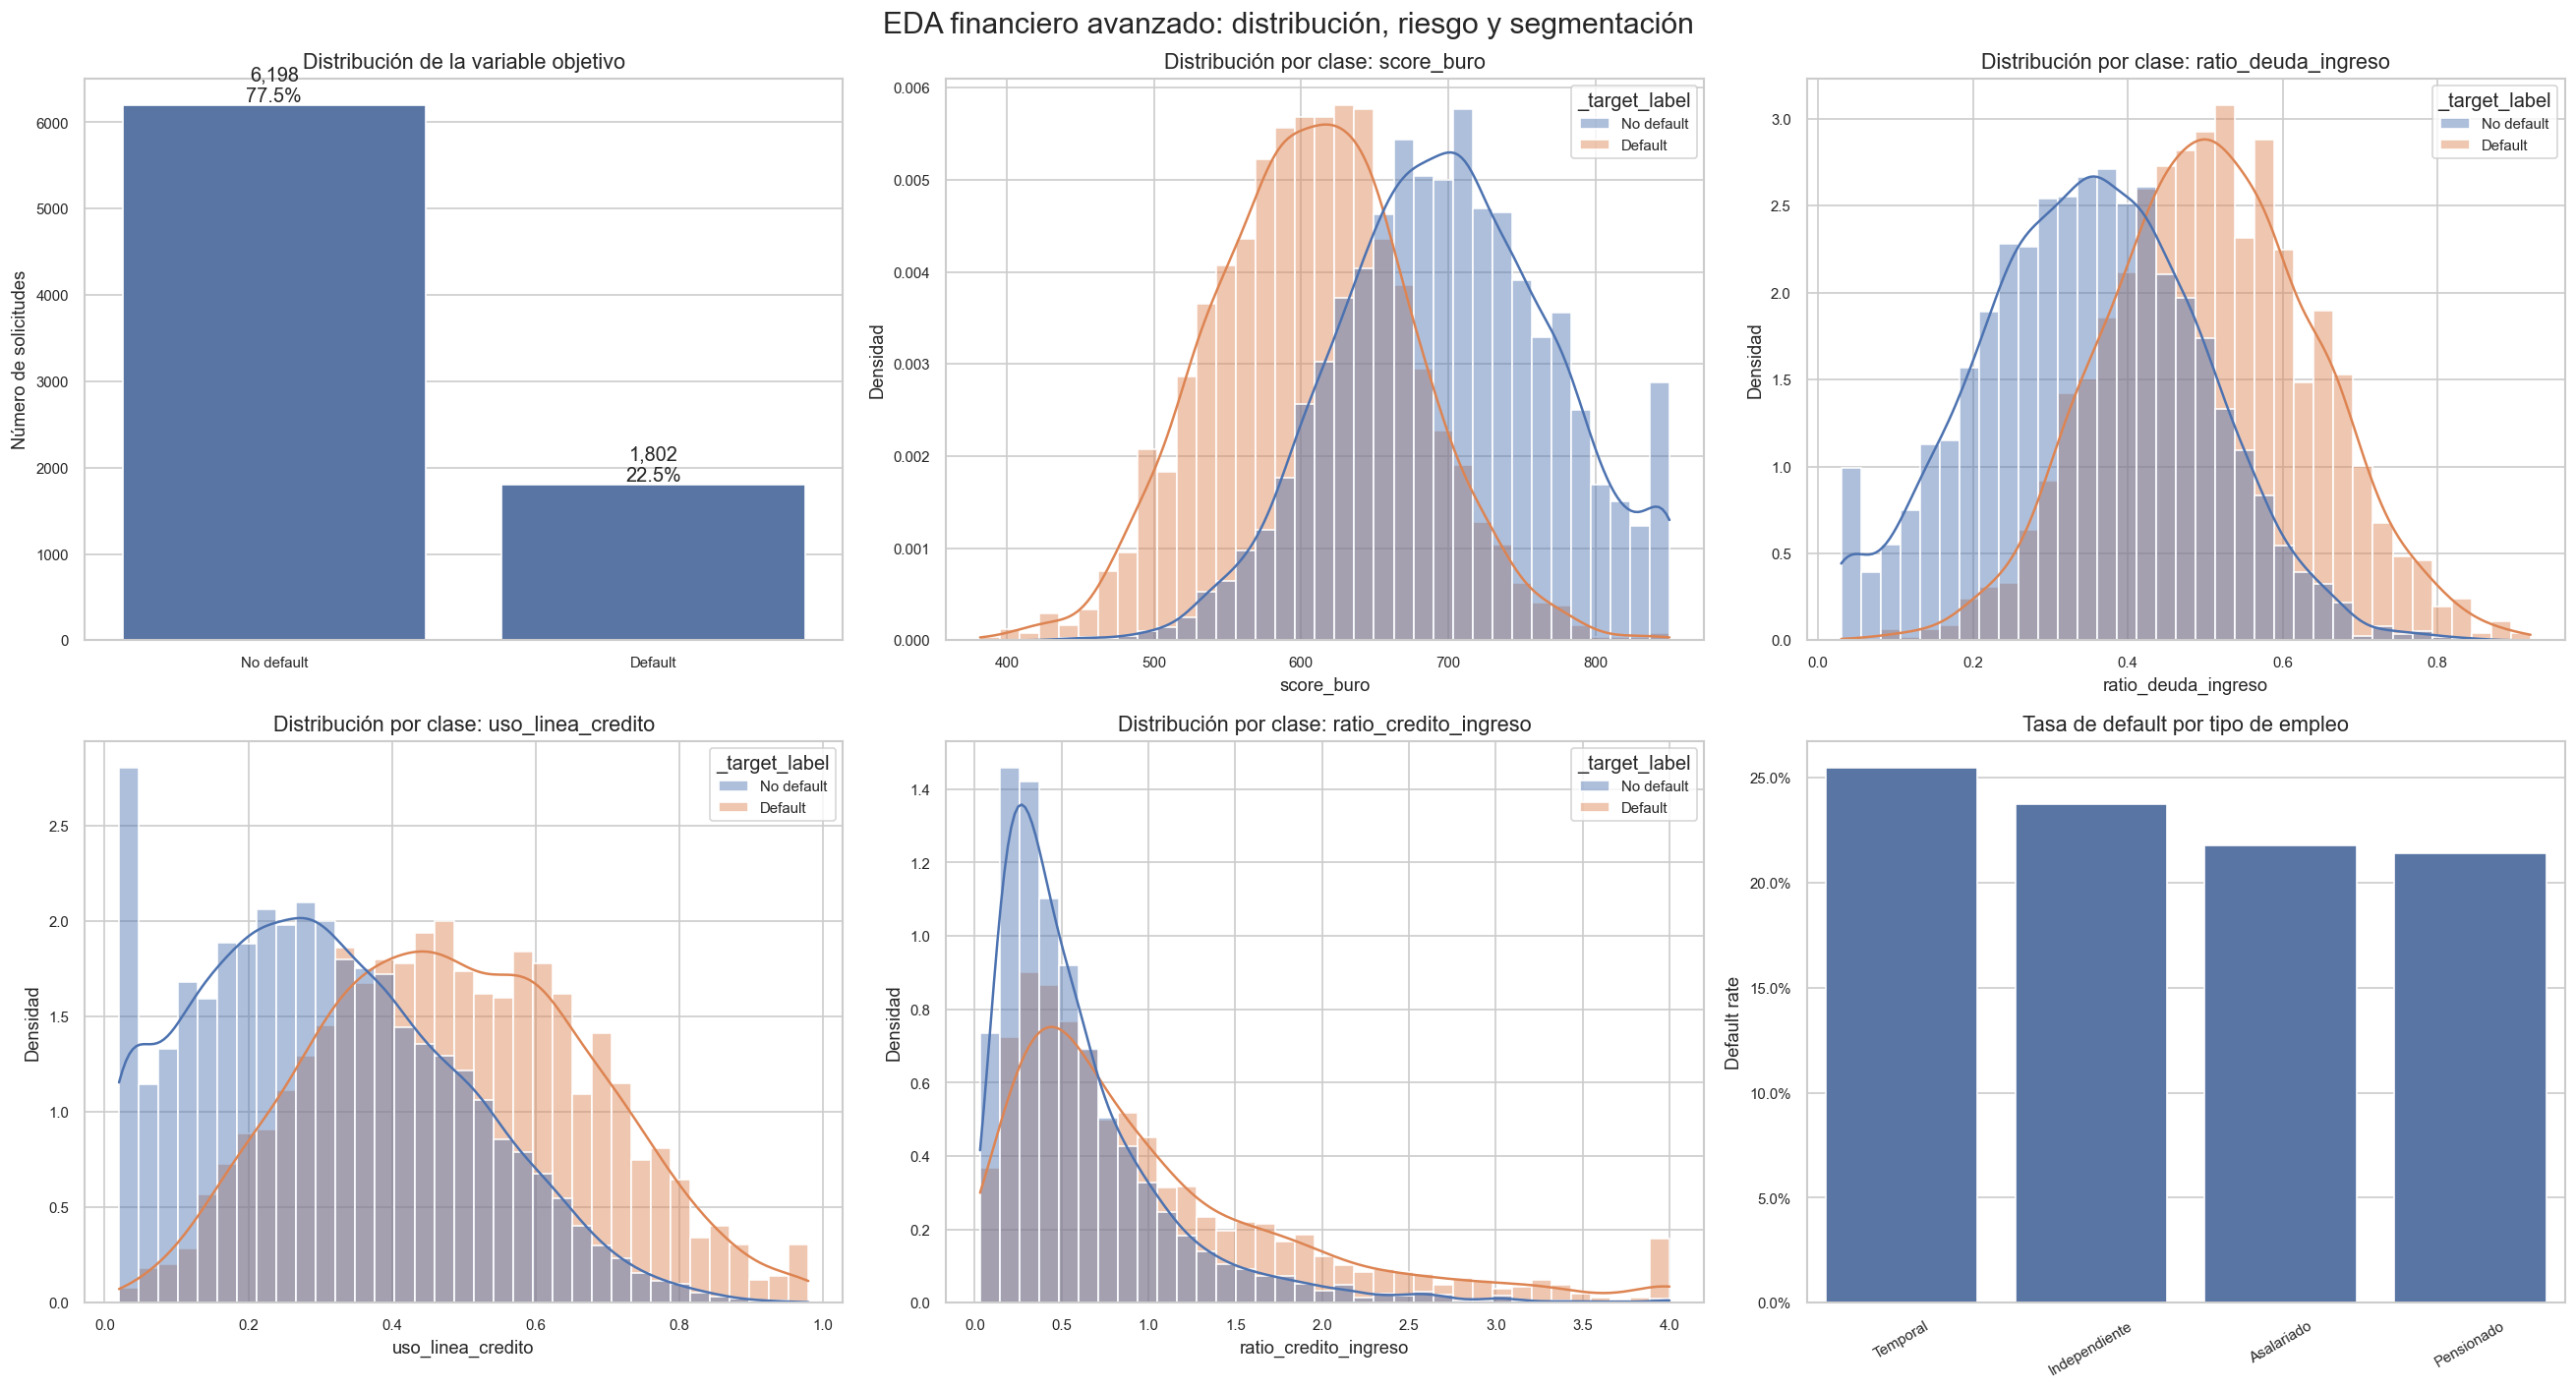

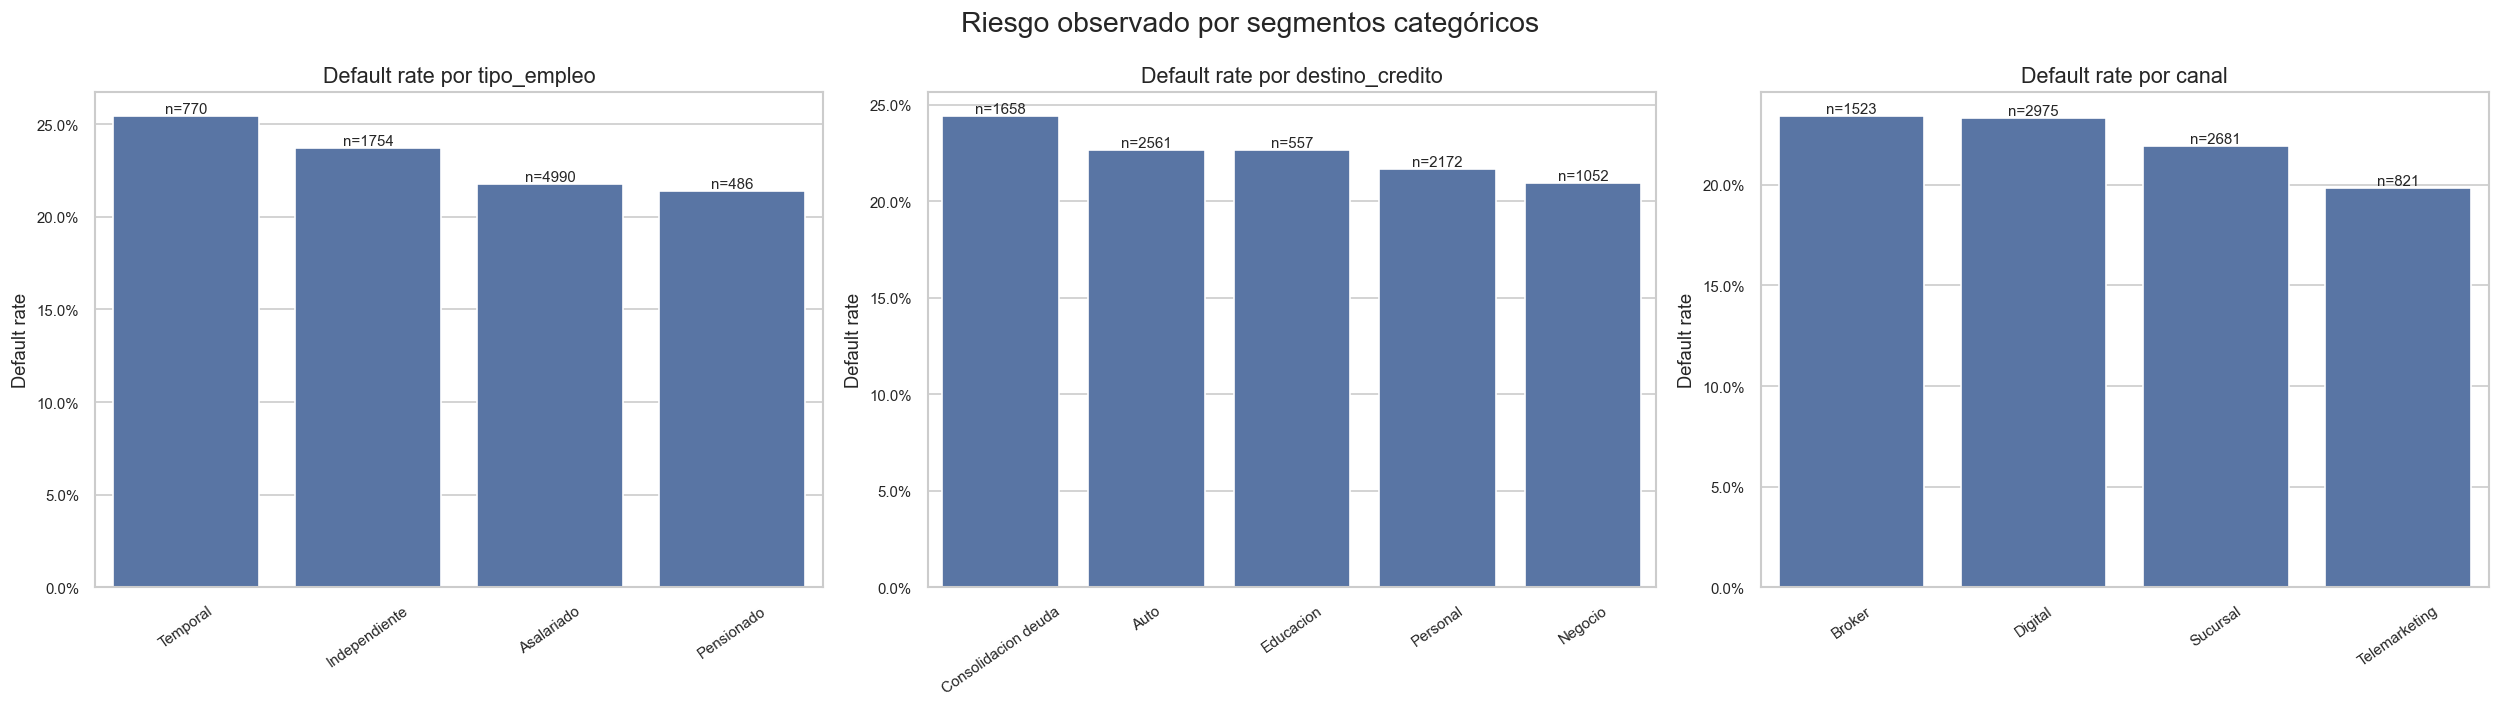

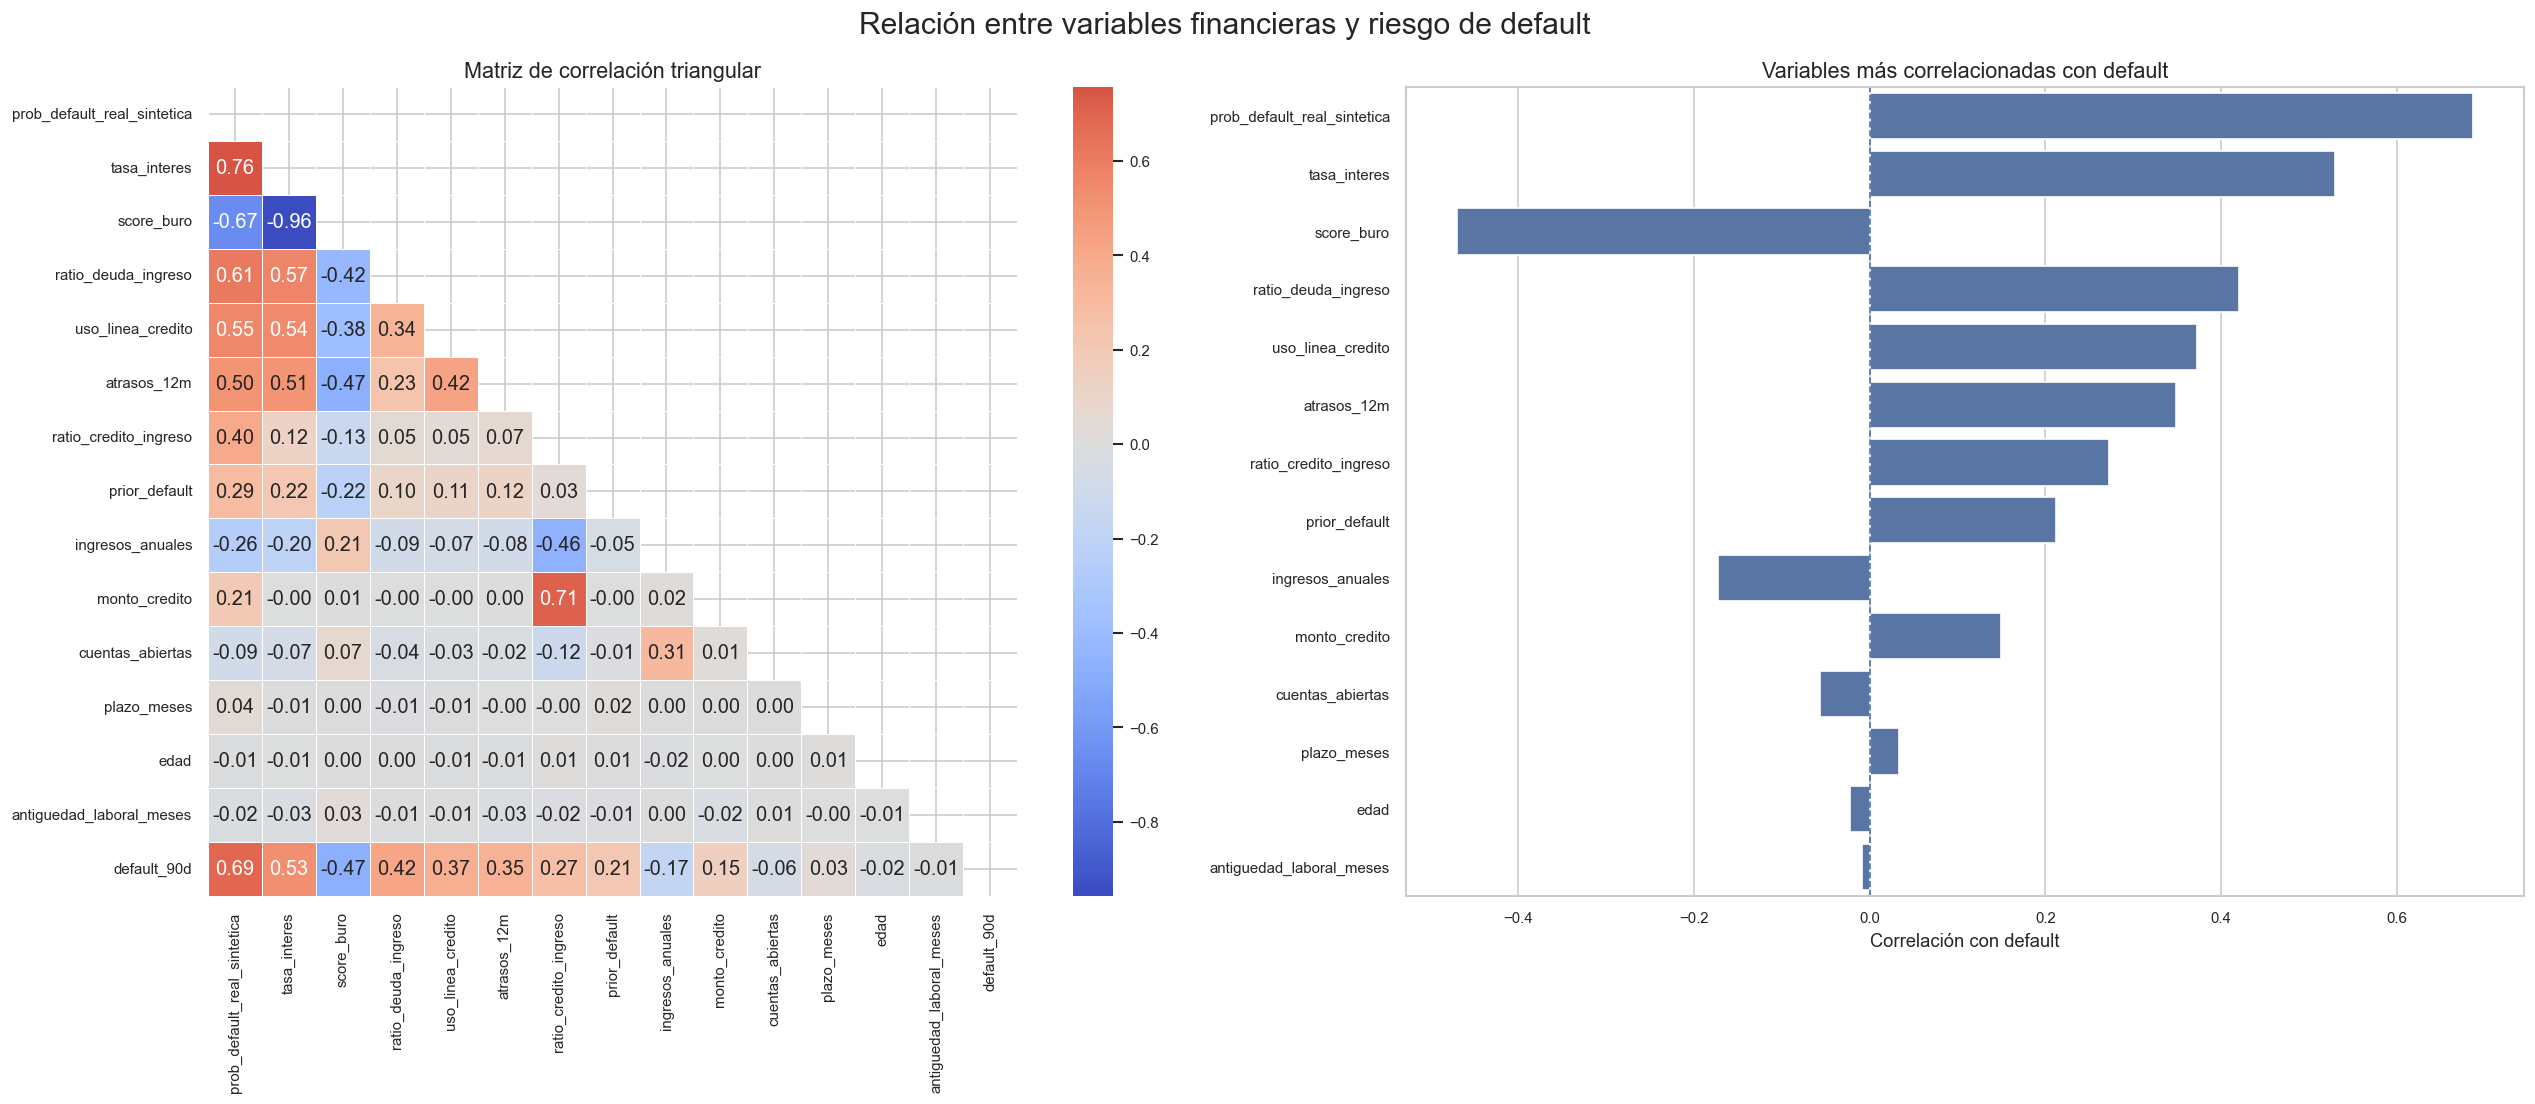

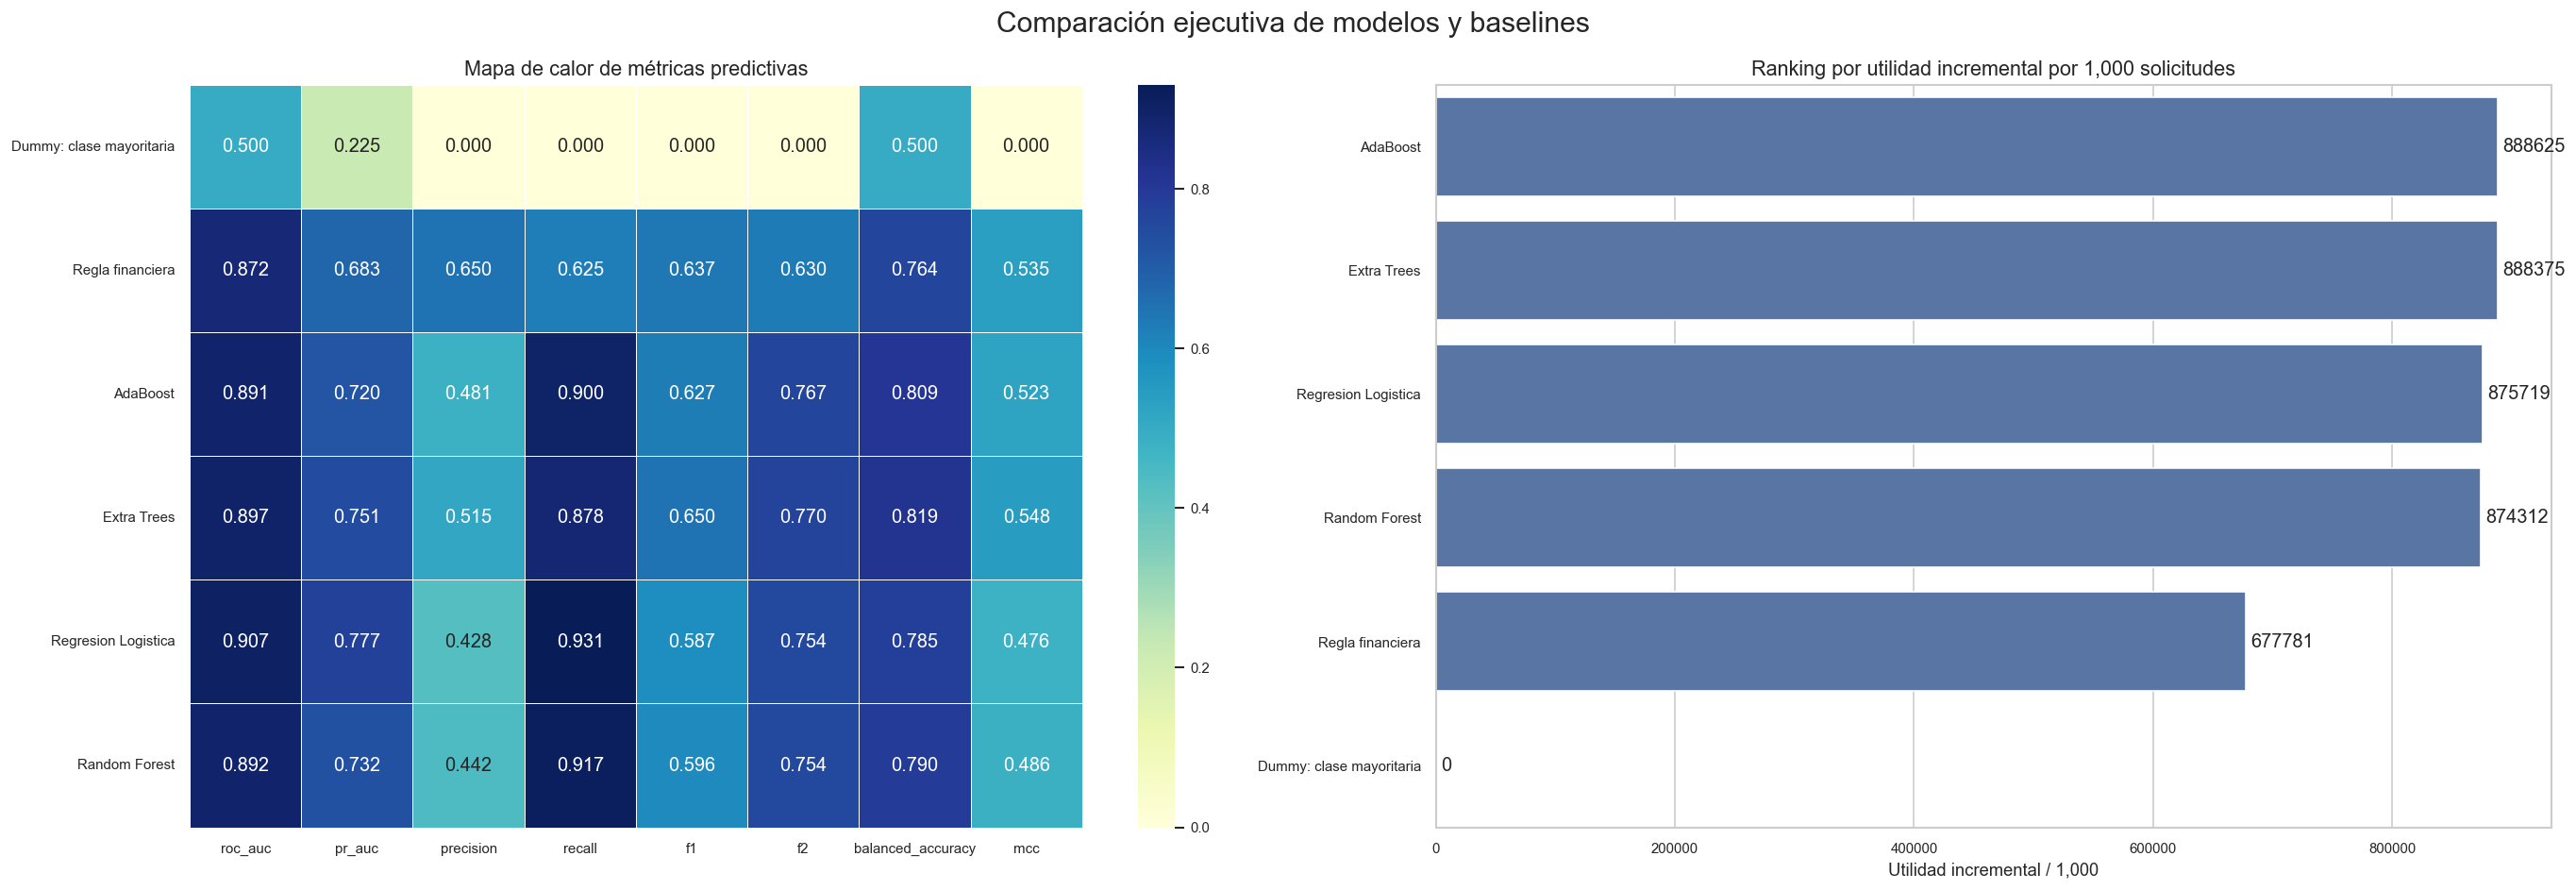

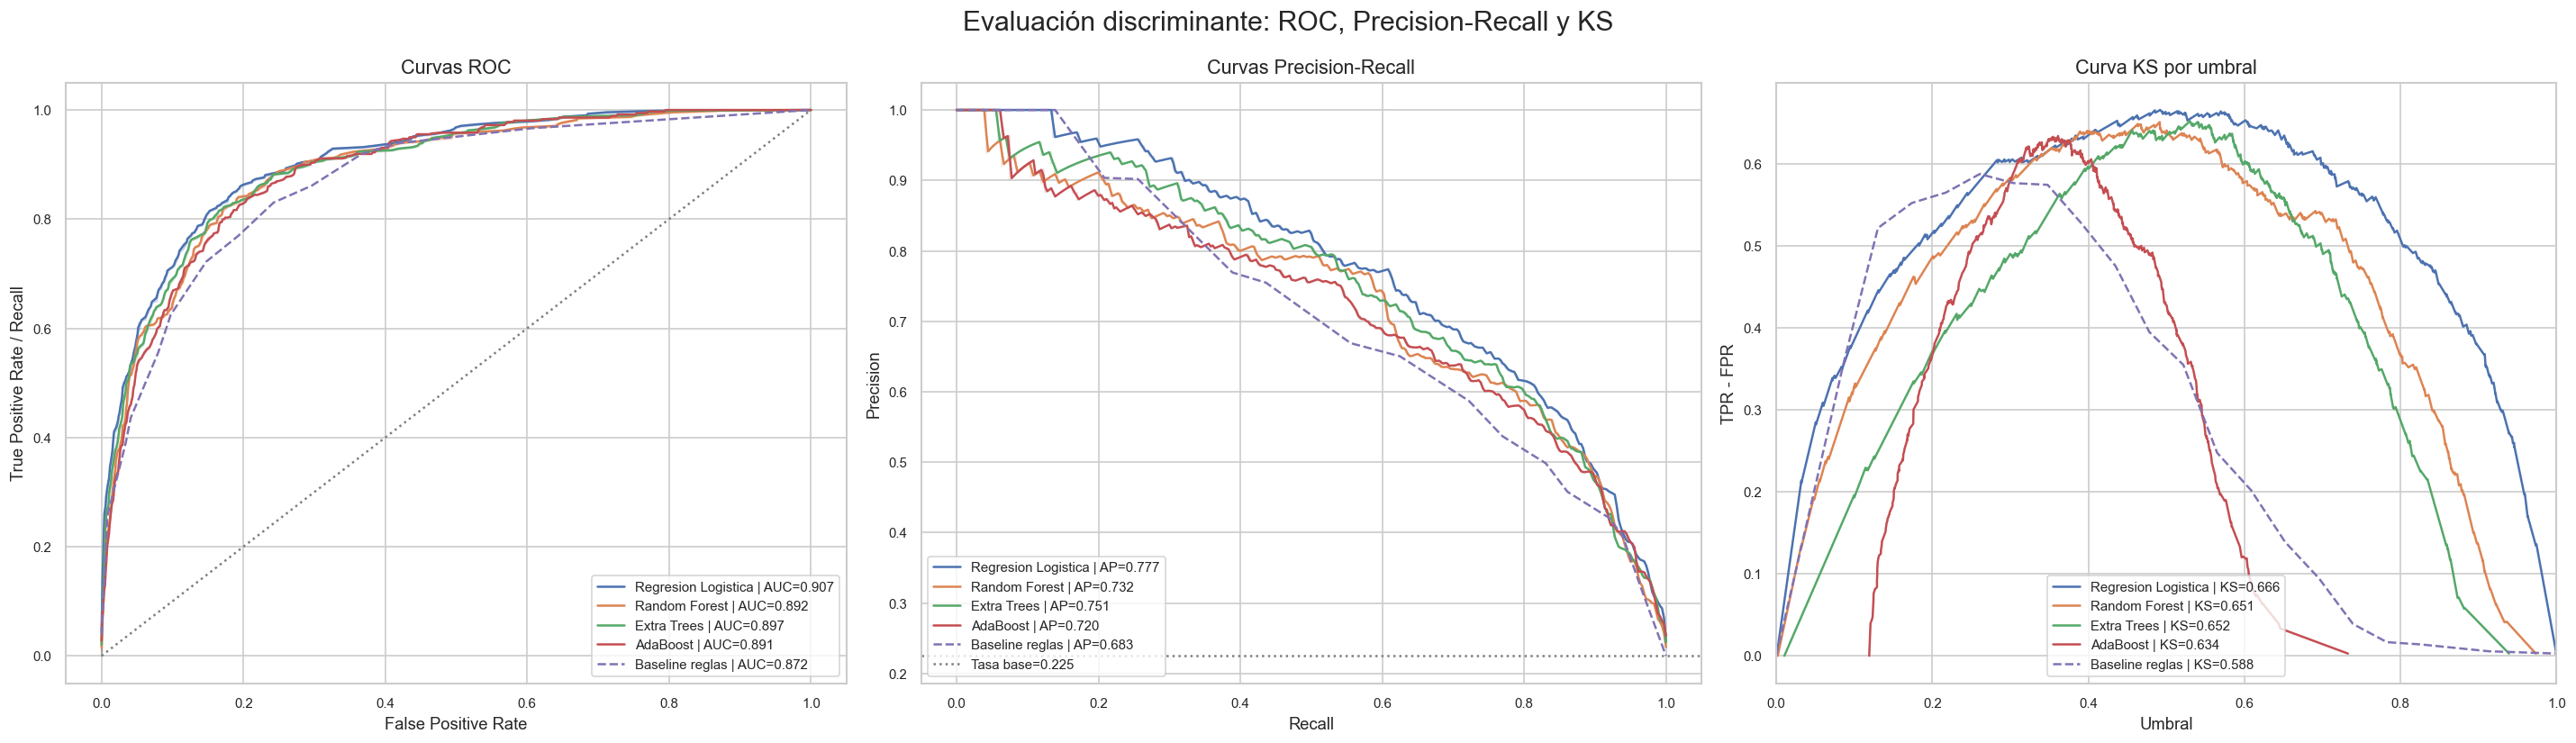

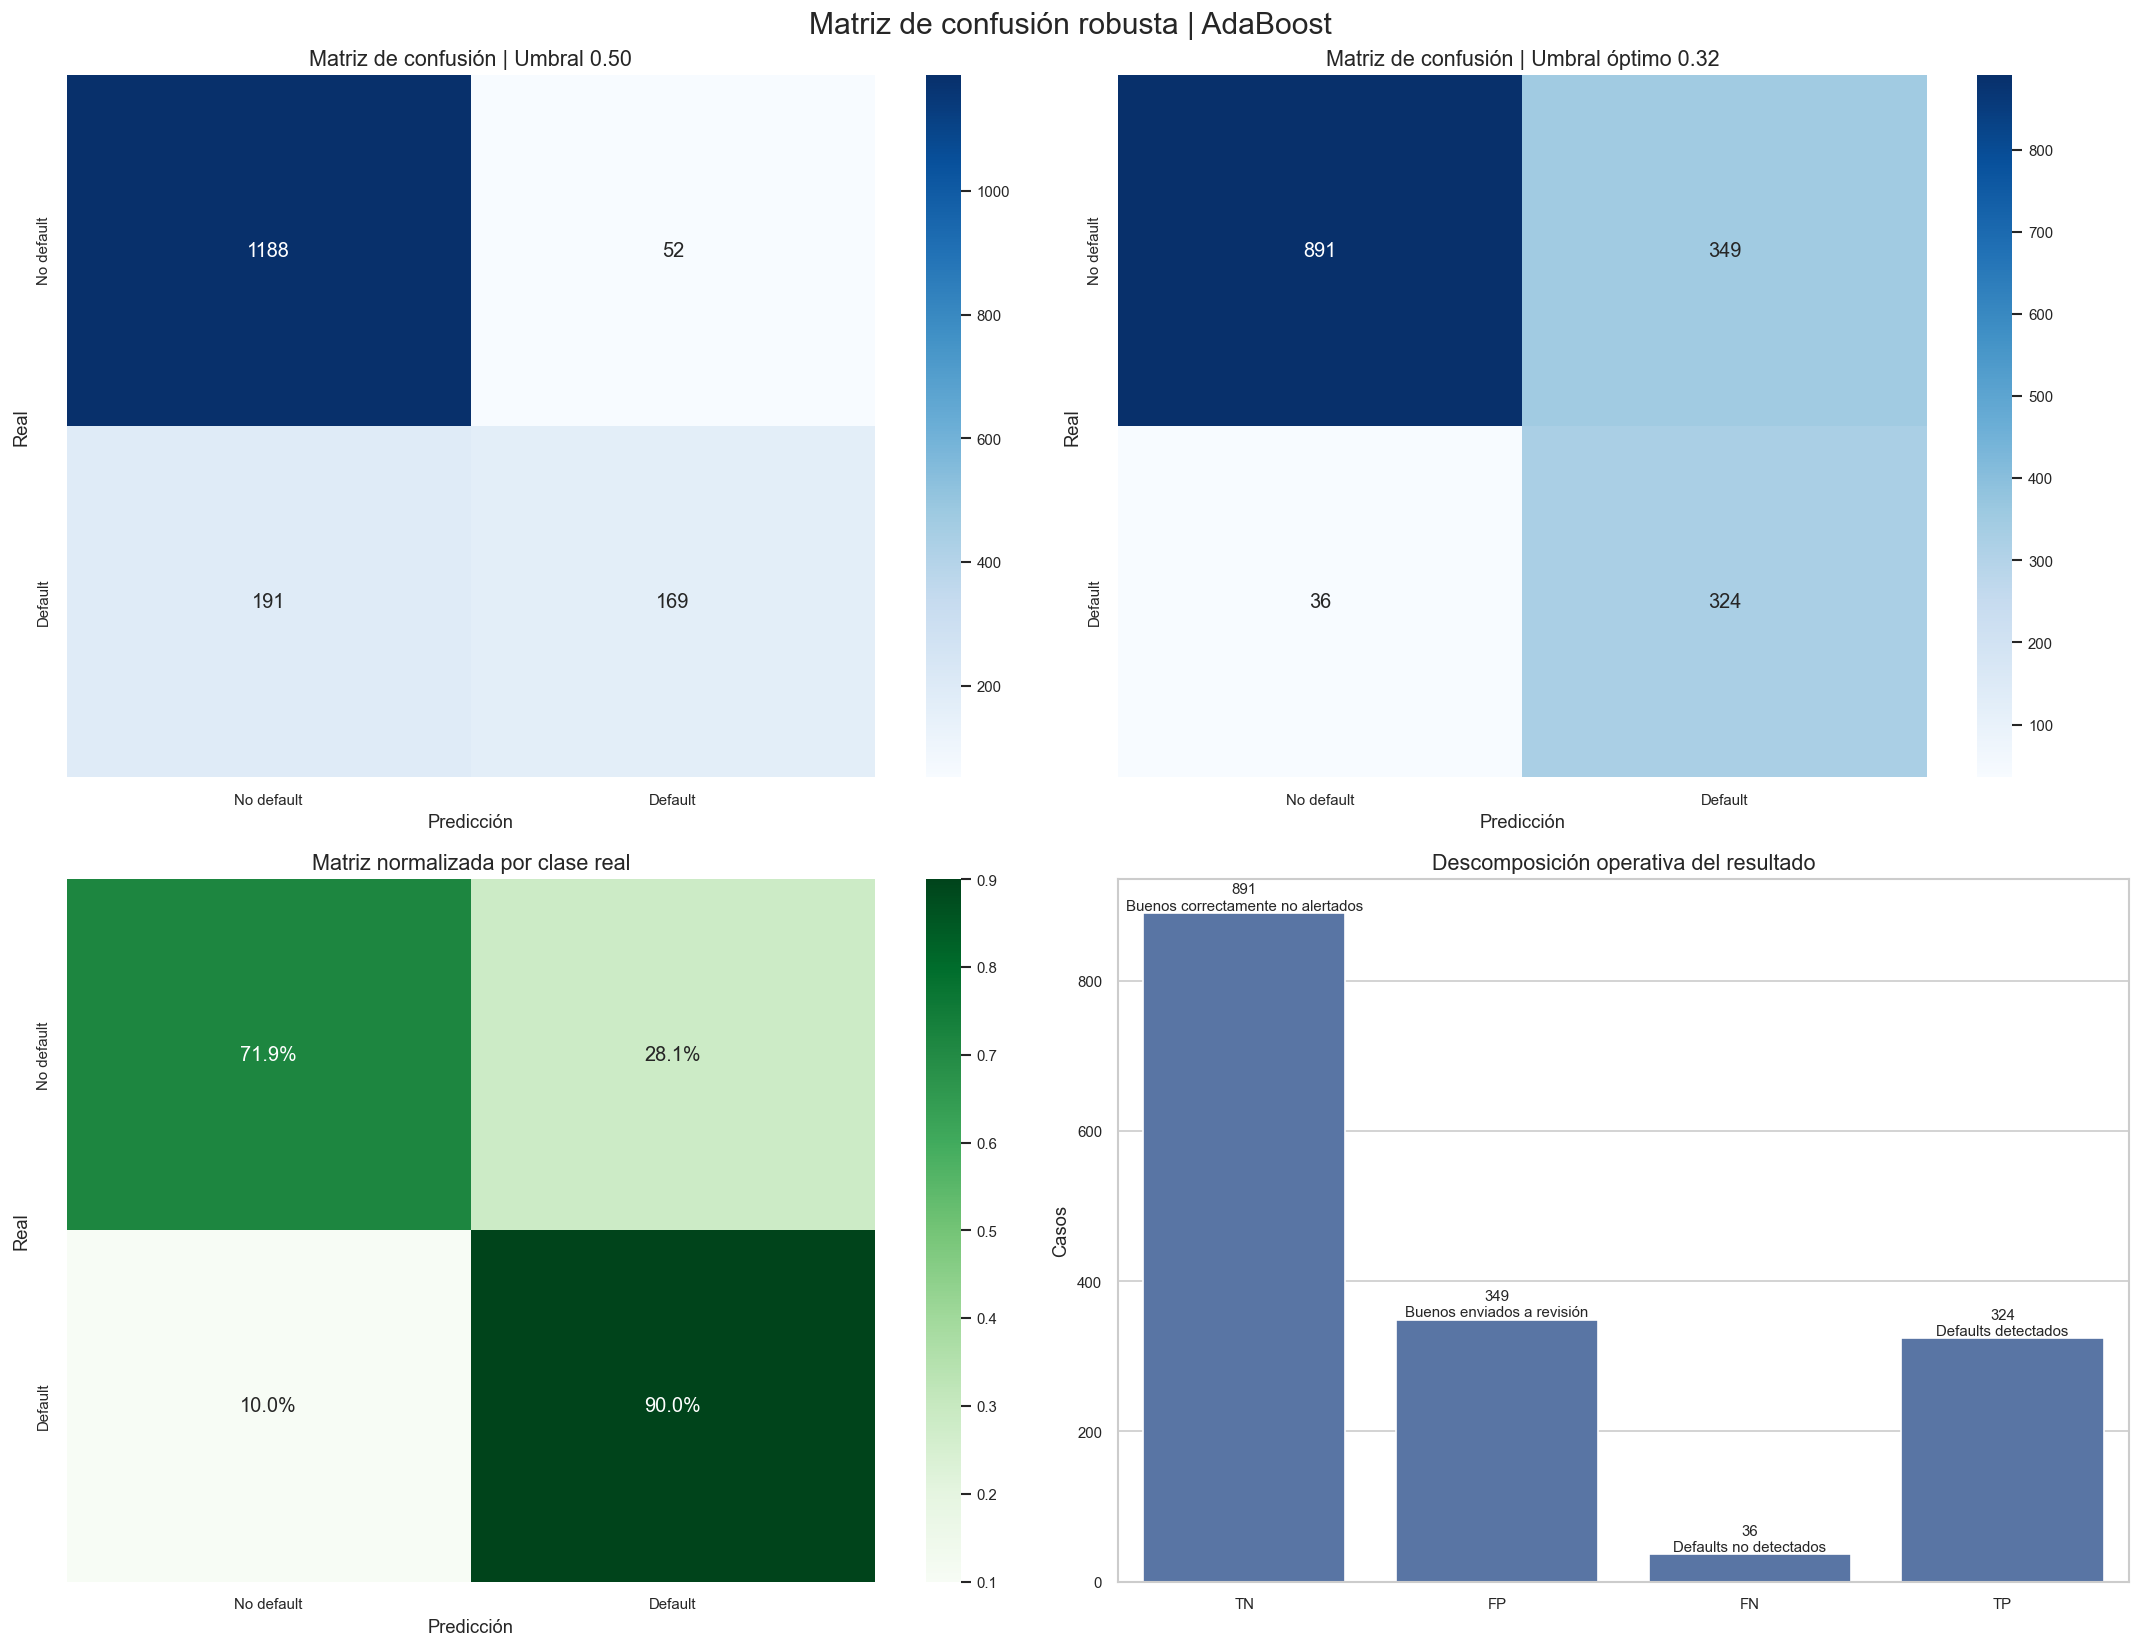

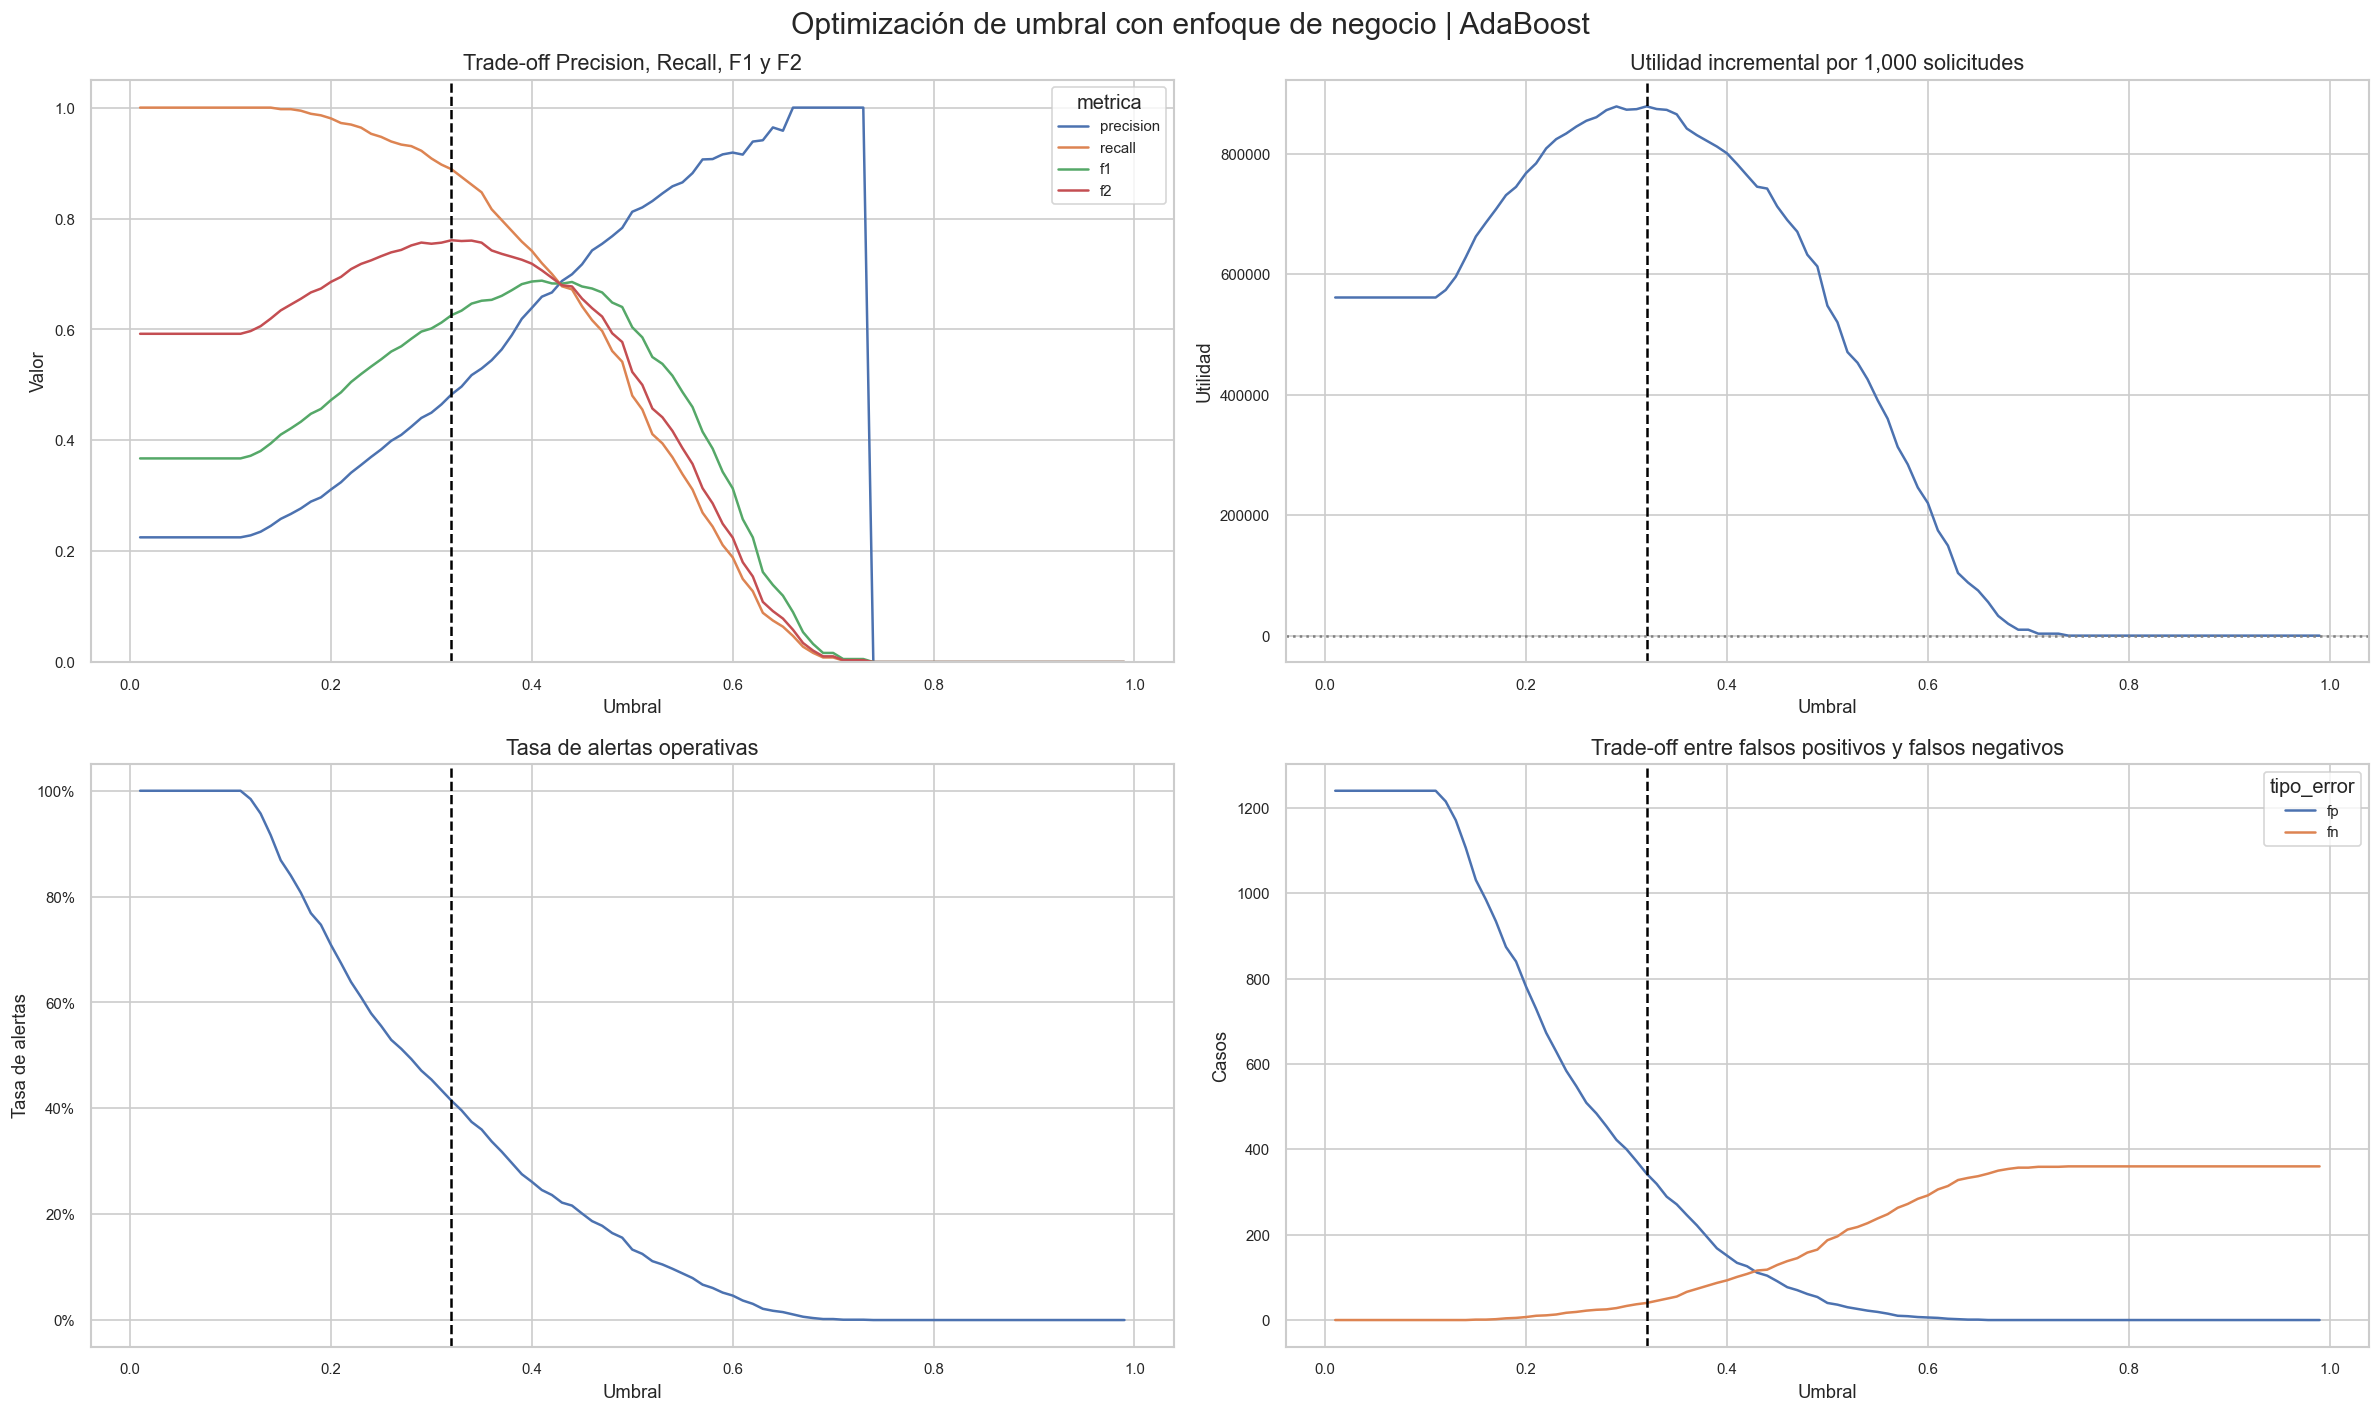

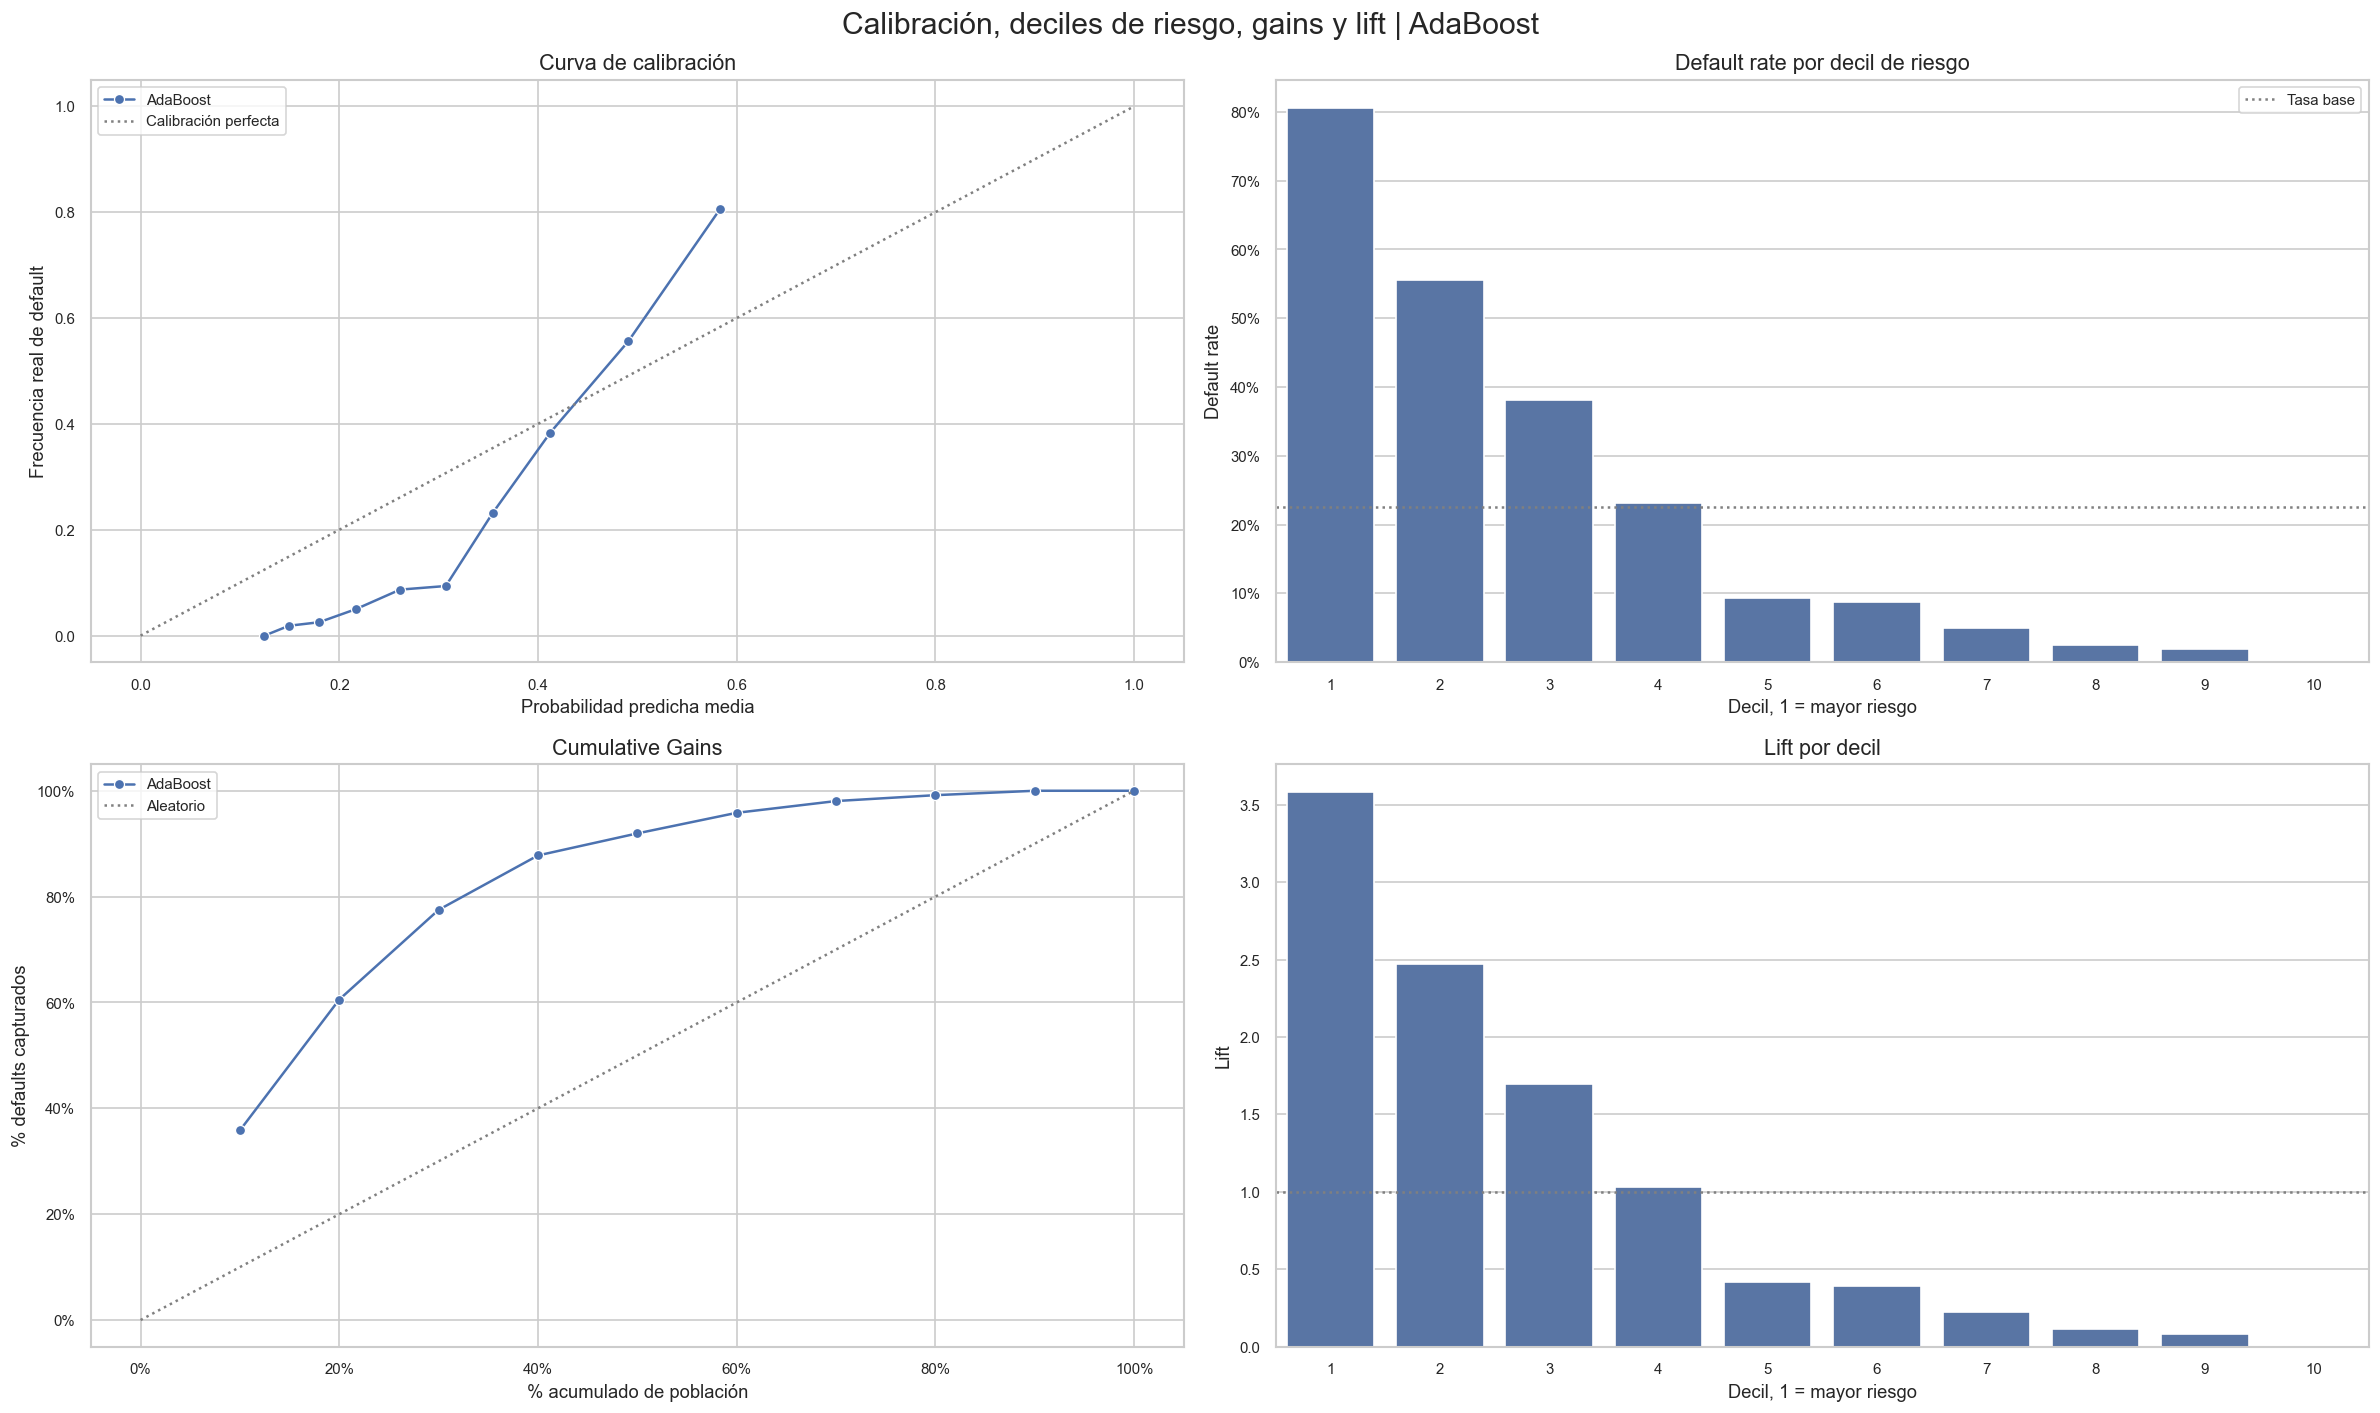

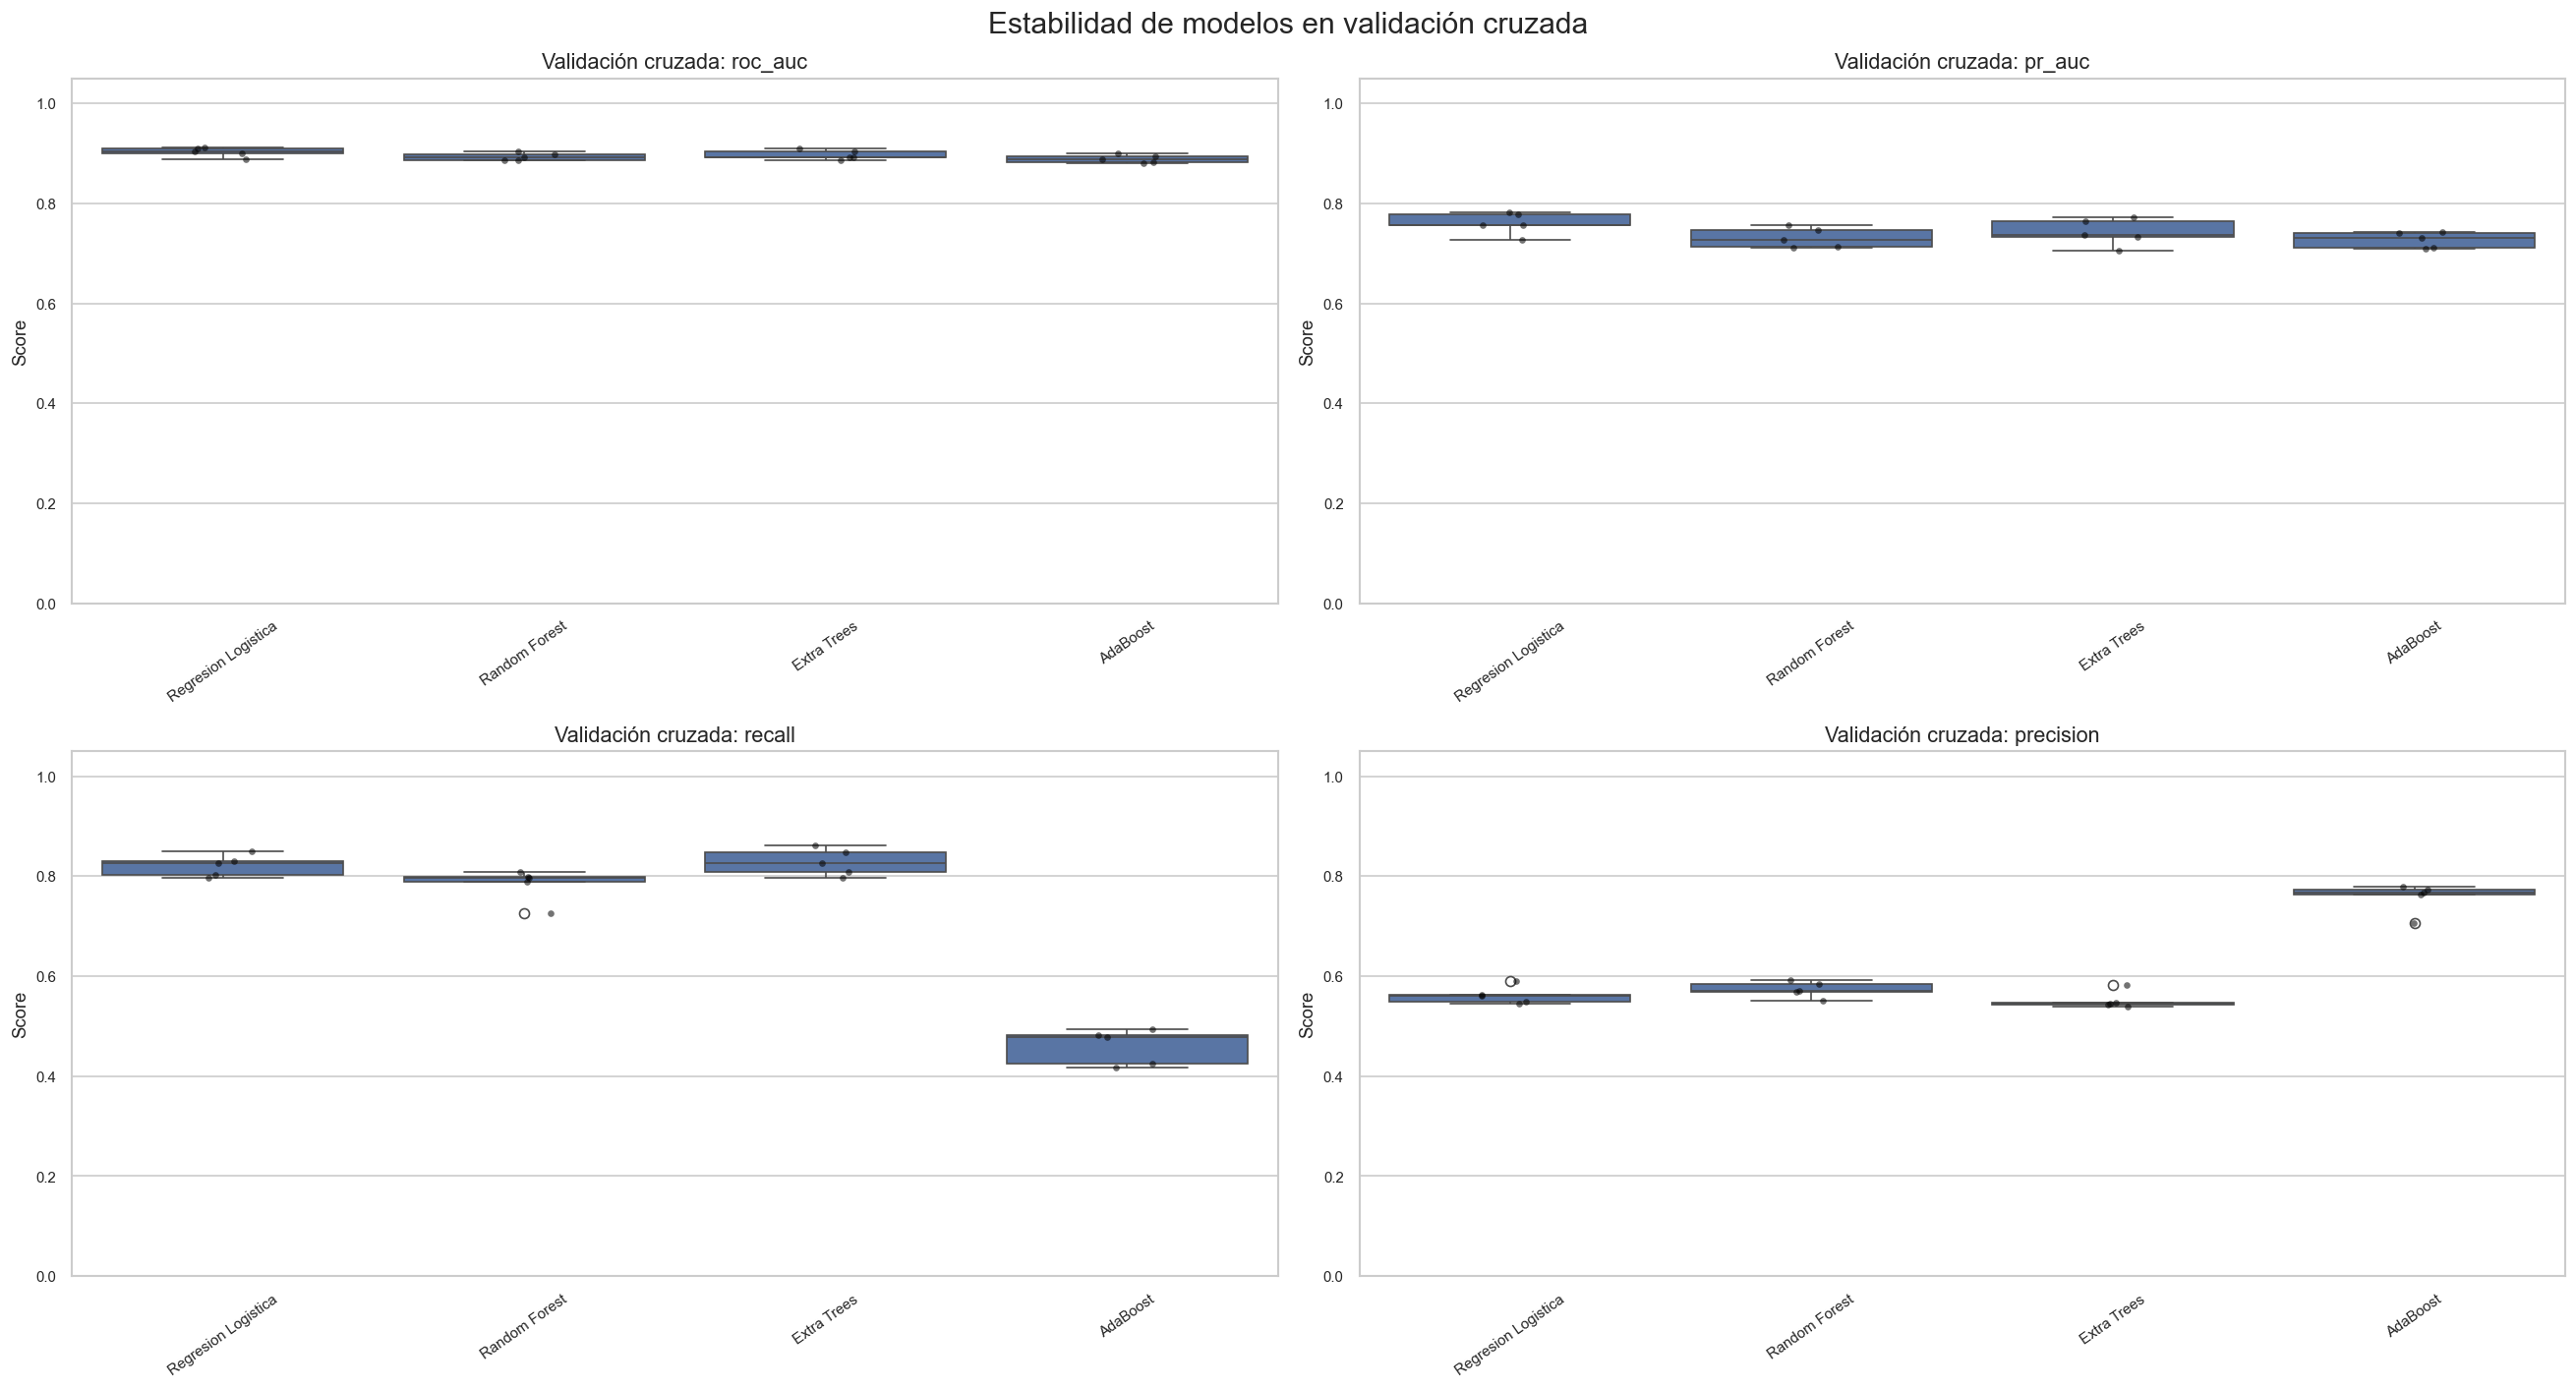

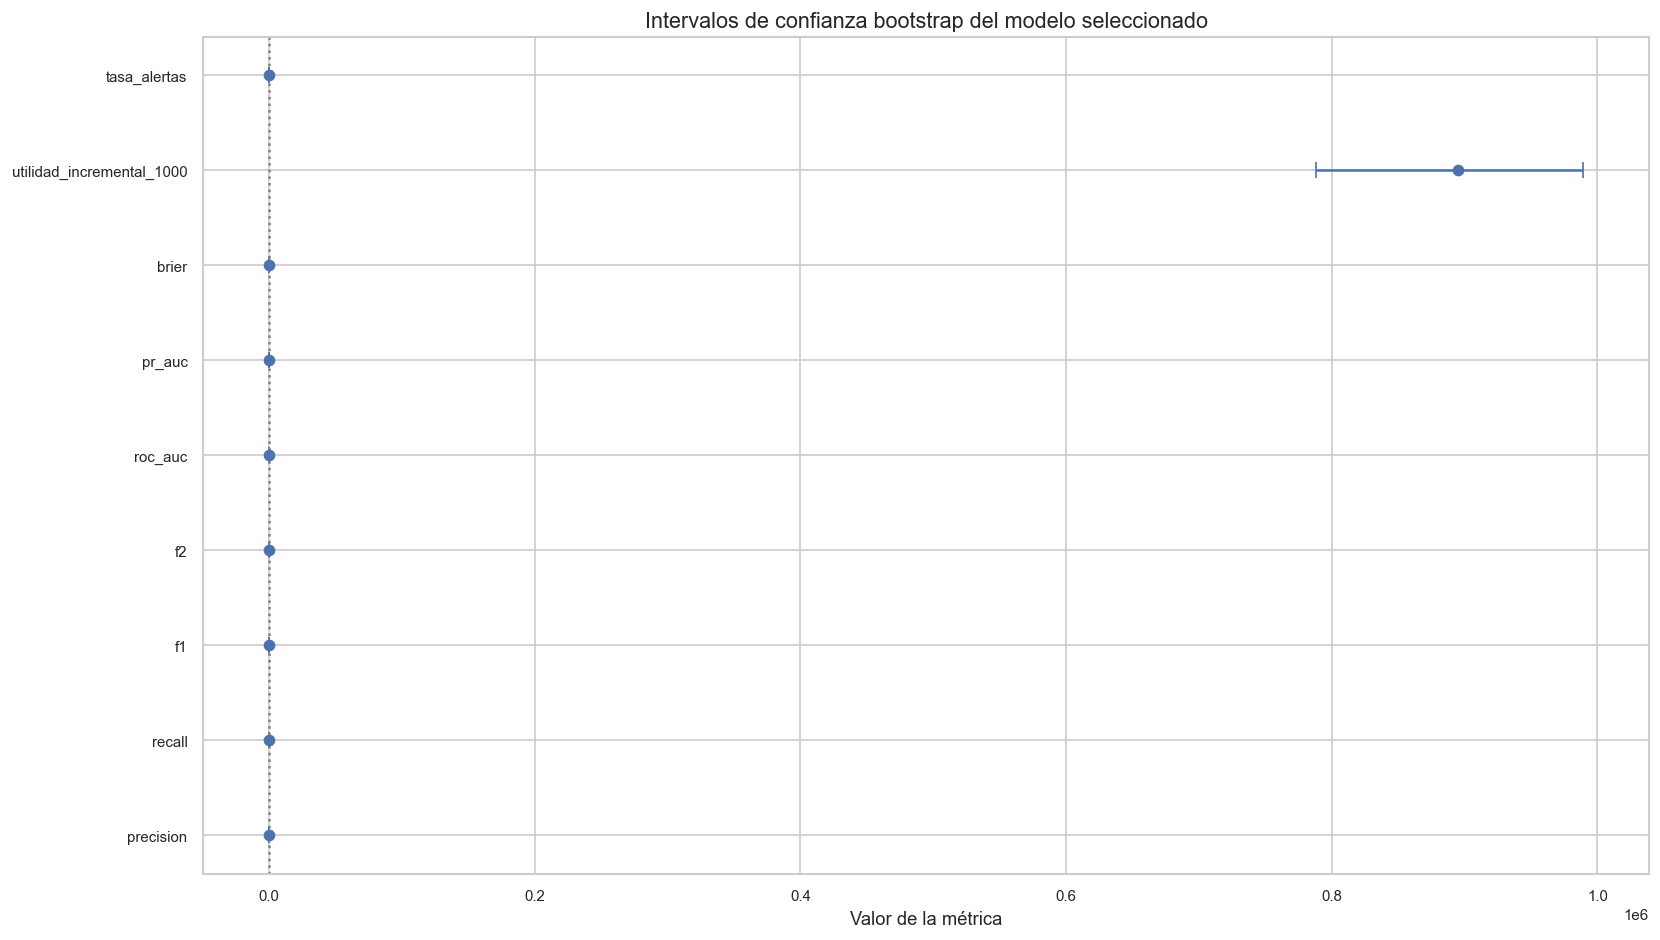

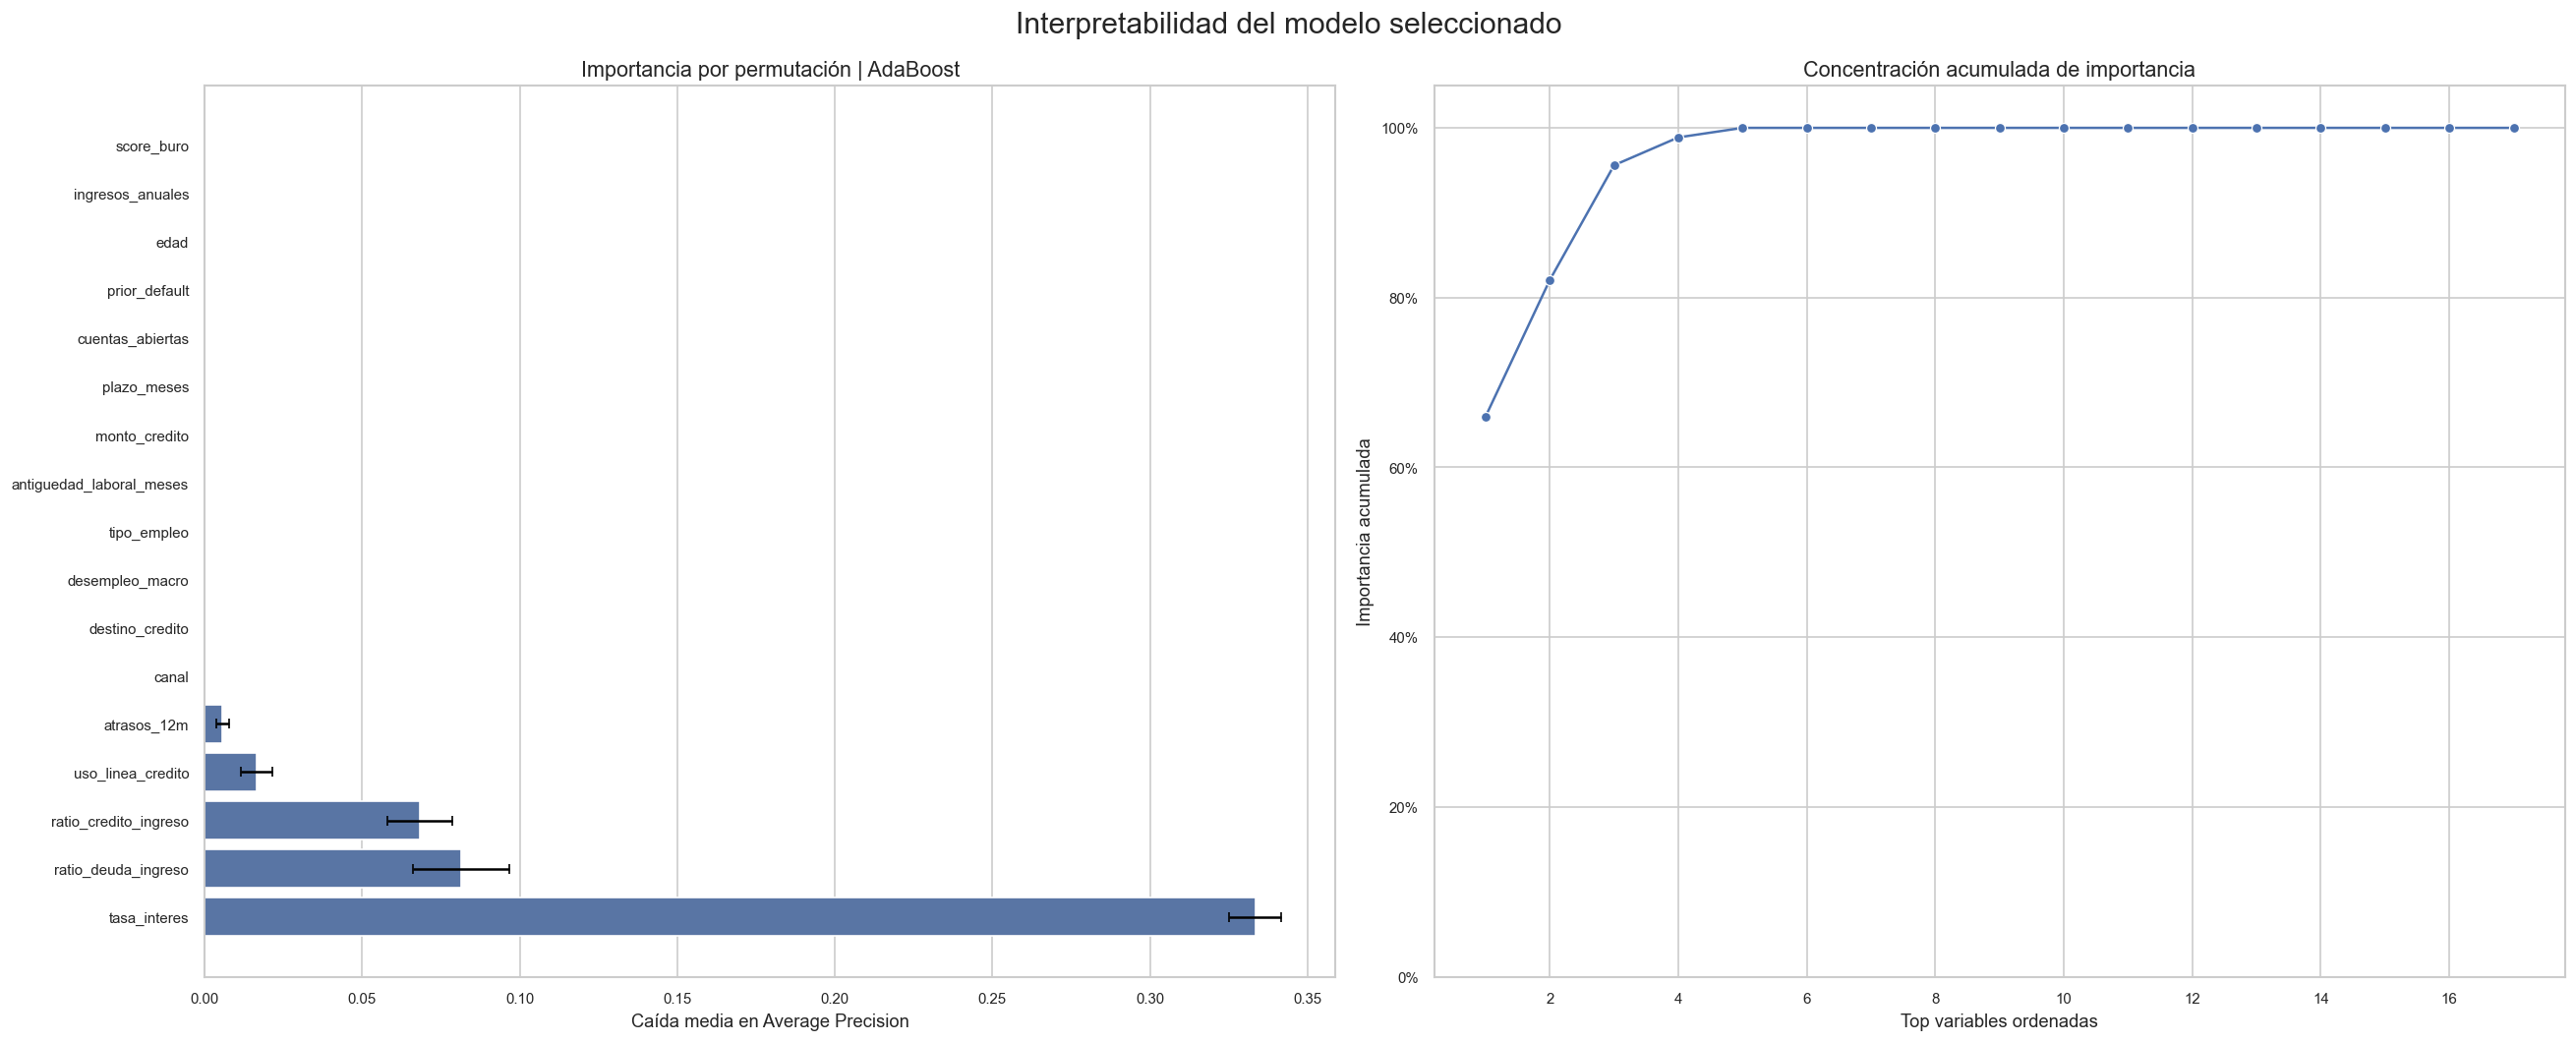

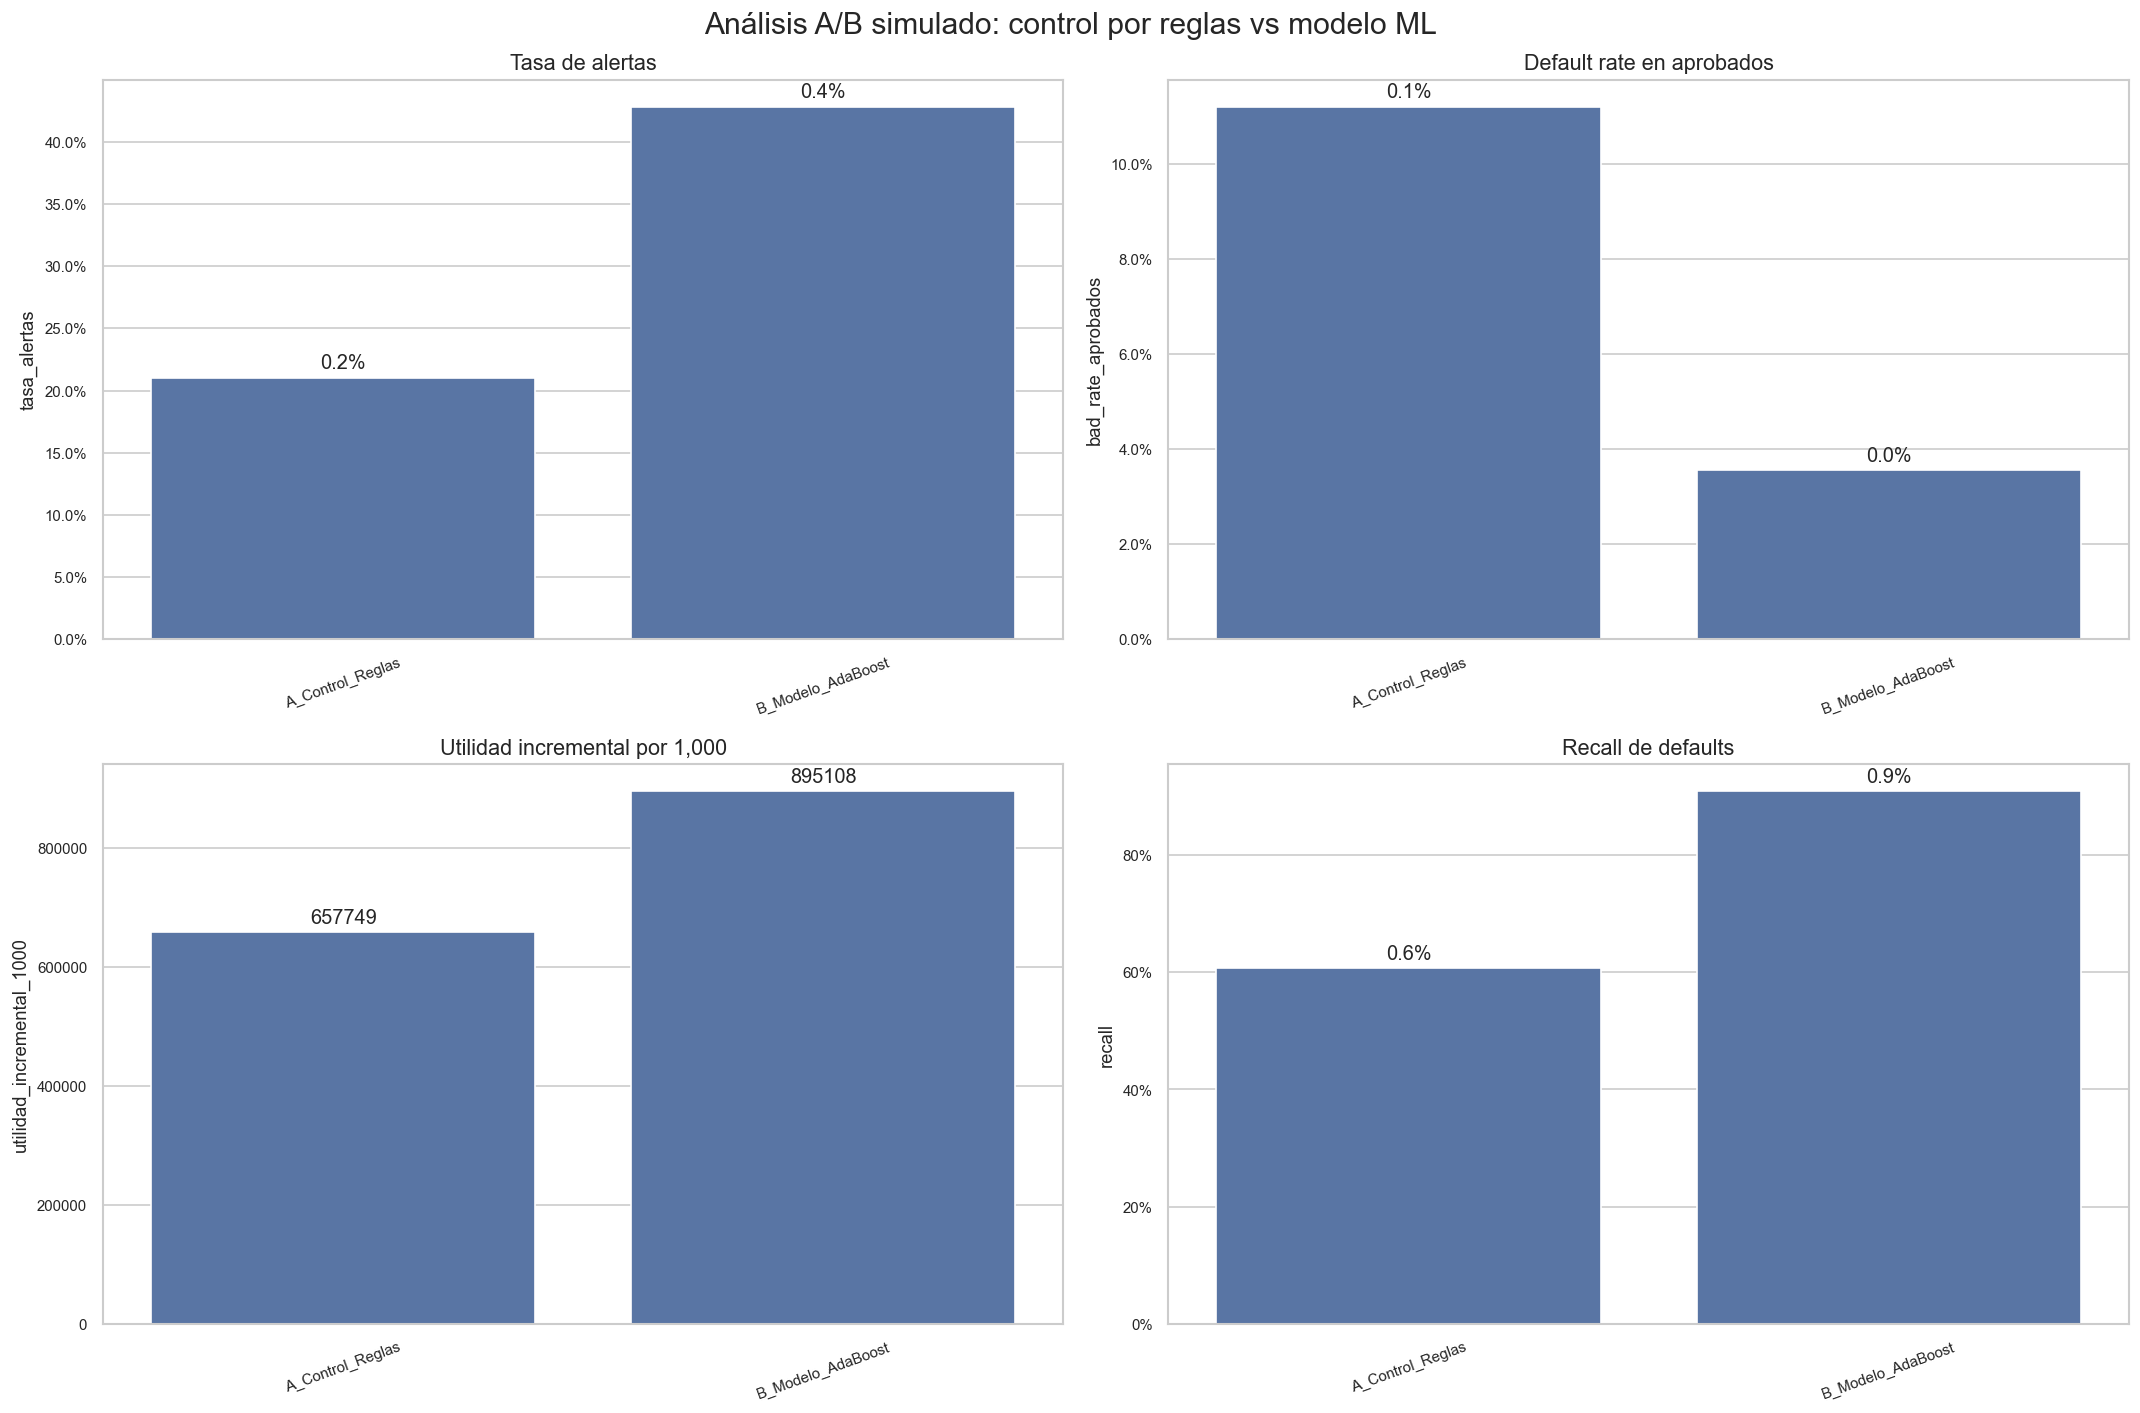

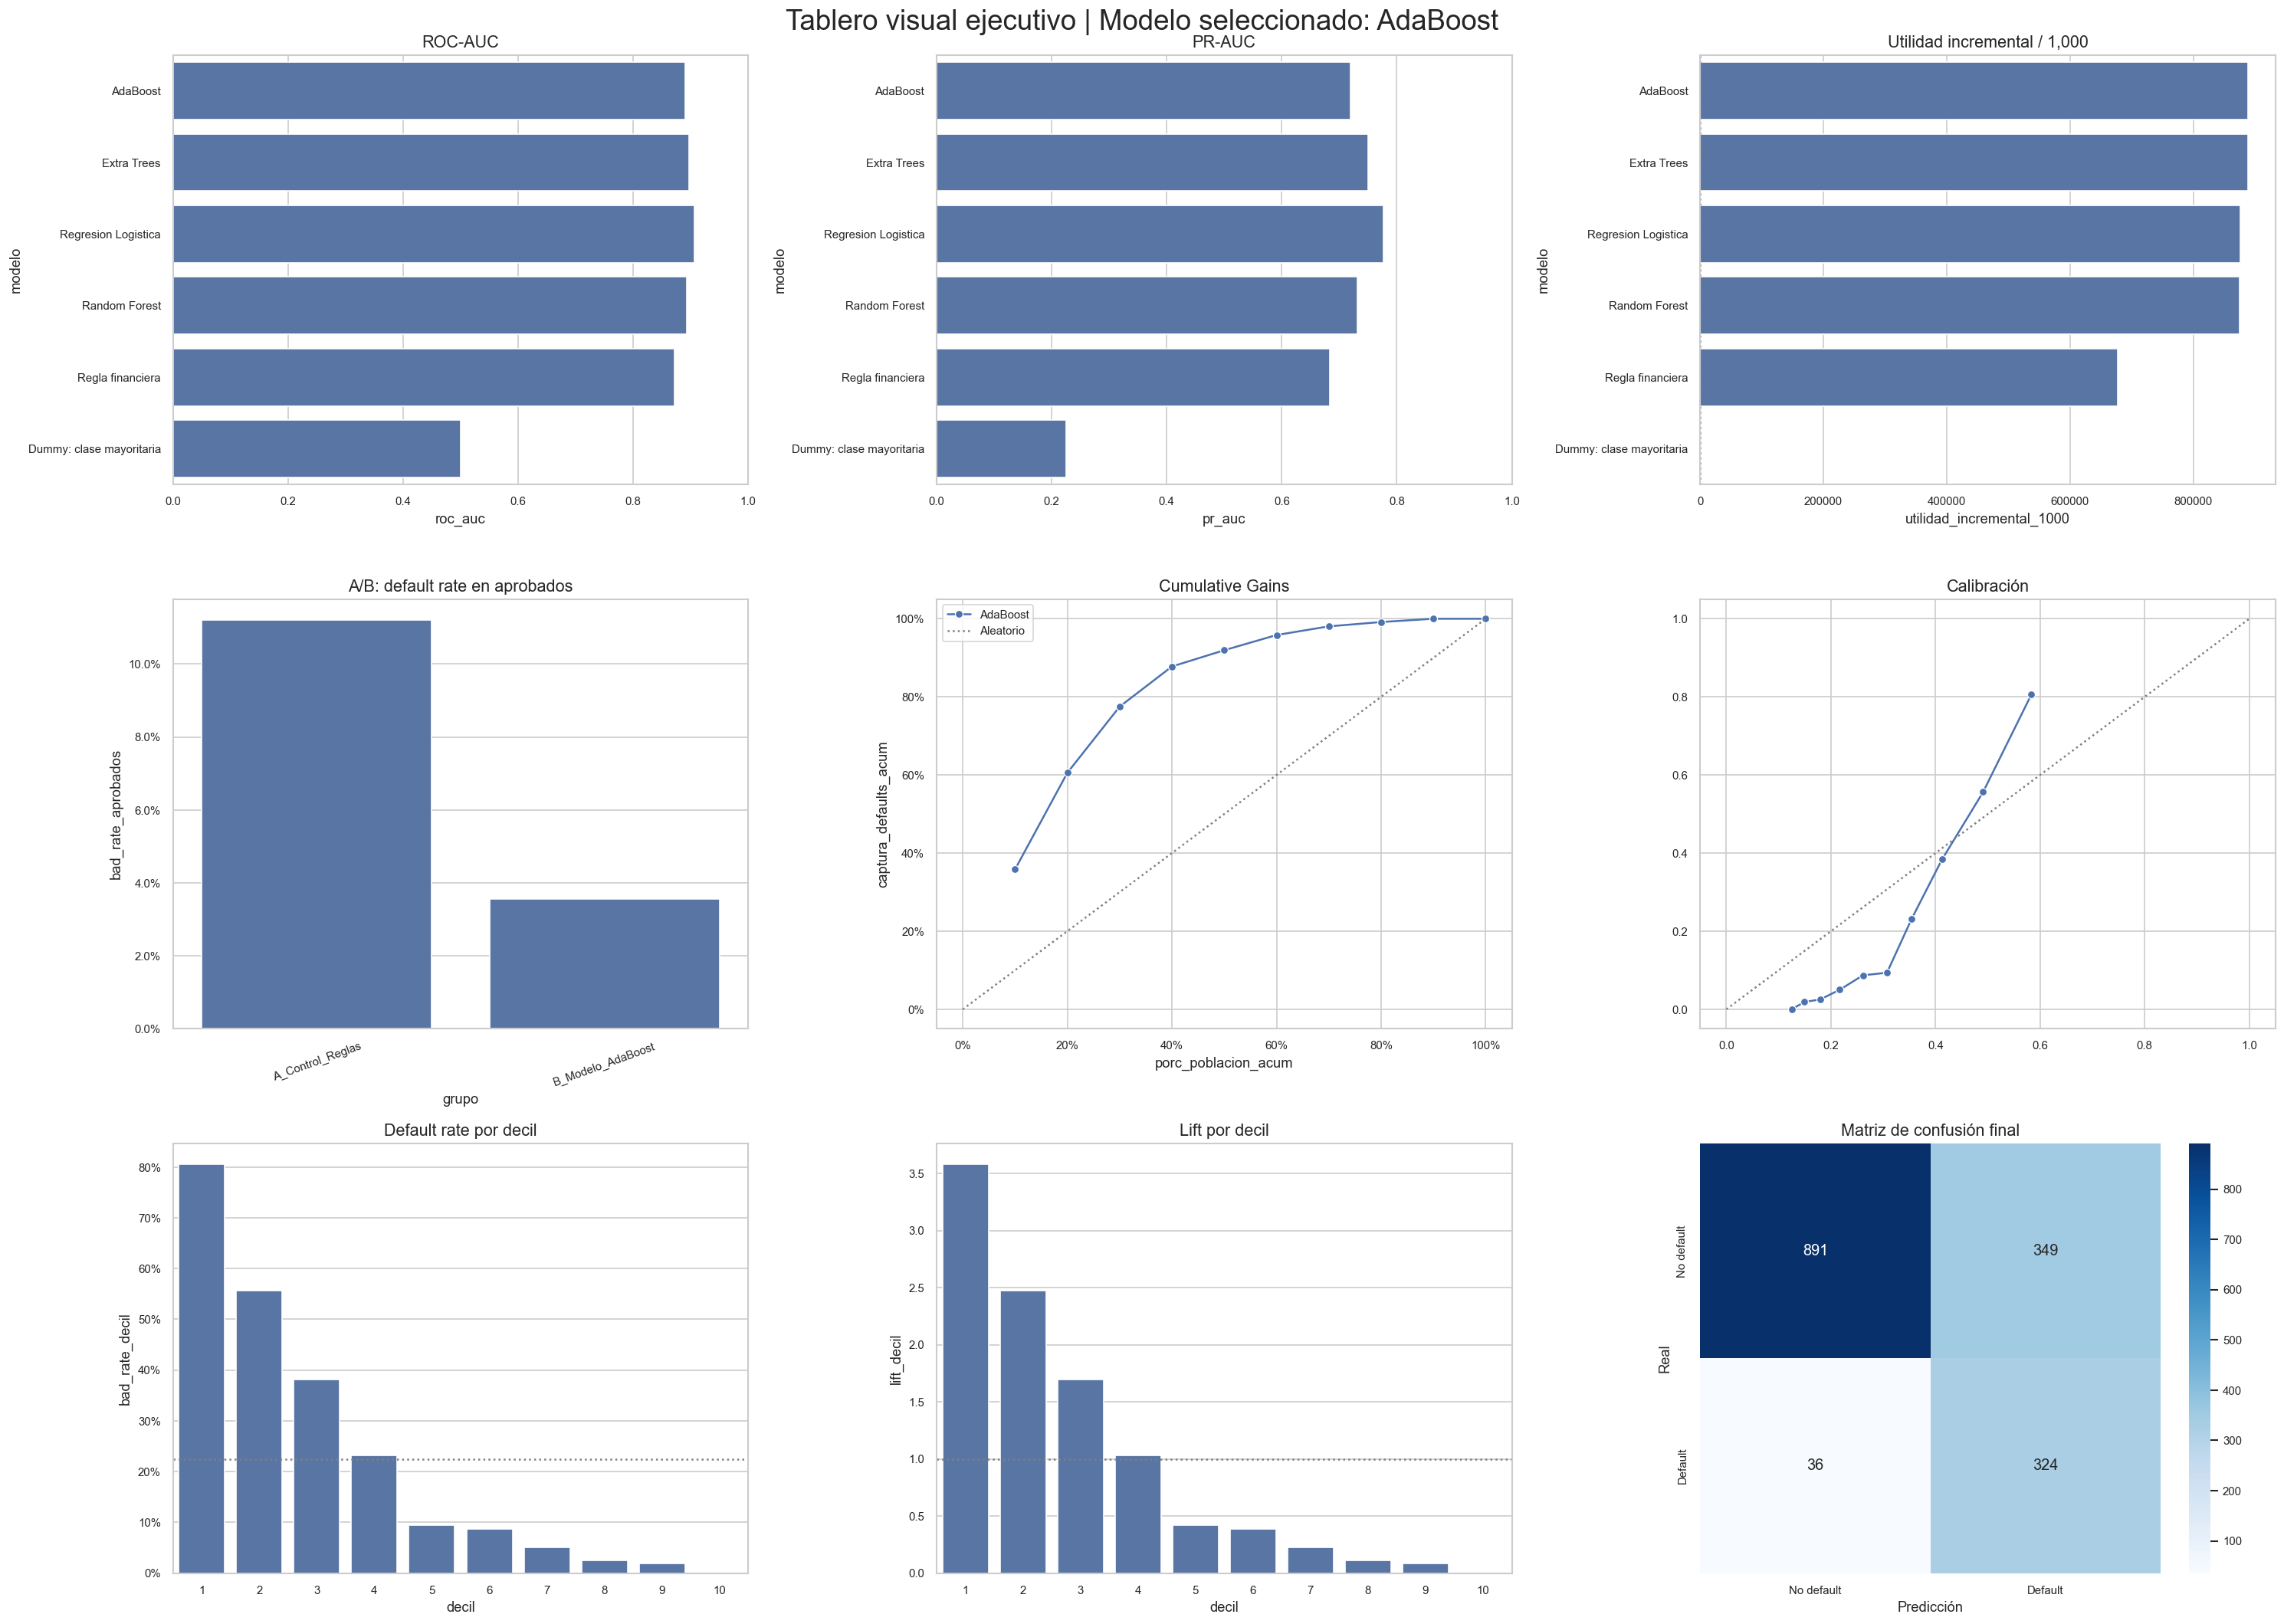


CONCLUSIÓN AUTOMÁTICA DEL EXPERIMENTO
Modelo seleccionado: AdaBoost
Umbral operativo recomendado: 0.32
ROC-AUC: 0.8907
PR-AUC: 0.7201
Precision: 0.4814
Recall: 0.9000
F2: 0.7667
Brier Score: 0.1284
Utilidad incremental por 1,000 solicitudes: 888,625.00
Cumple objetivo SMART: True


In [5]:
try:
    import seaborn as sns
except ImportError:
    raise ImportError("Instala seaborn")

from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 16
})


def preparar_metricas_para_graficar(metricas_comparacion):
    df_plot = metricas_comparacion.copy().reset_index()
    df_plot = df_plot.rename(columns={df_plot.columns[0]: "modelo"})
    return df_plot


def graficar_eda_financiero_avanzado(df, target_col):
    df_plot = df.copy()
    df_plot["_target_label"] = df_plot[target_col].map({
        0: "No default",
        1: "Default"
    })

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    axes = axes.ravel()

    conteo = (
        df_plot["_target_label"]
        .value_counts()
        .reindex(["No default", "Default"])
        .reset_index()
    )
    conteo.columns = ["clase", "casos"]
    conteo["porcentaje"] = conteo["casos"] / conteo["casos"].sum()

    sns.barplot(
        data=conteo,
        x="clase",
        y="casos",
        ax=axes[0]
    )
    axes[0].set_title("Distribución de la variable objetivo")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Número de solicitudes")

    for i, row in conteo.iterrows():
        axes[0].text(
            i,
            row["casos"],
            f"{row['casos']:,}\n{row['porcentaje']:.1%}",
            ha="center",
            va="bottom"
        )

    variables_hist = [
        "score_buro",
        "ratio_deuda_ingreso",
        "uso_linea_credito",
        "ratio_credito_ingreso"
    ]

    variables_hist = [v for v in variables_hist if v in df_plot.columns]

    for ax, variable in zip(axes[1:5], variables_hist):
        sns.histplot(
            data=df_plot,
            x=variable,
            hue="_target_label",
            kde=True,
            stat="density",
            common_norm=False,
            bins=35,
            alpha=0.45,
            ax=ax
        )
        ax.set_title(f"Distribución por clase: {variable}")
        ax.set_xlabel(variable)
        ax.set_ylabel("Densidad")

    if "tipo_empleo" in df_plot.columns:
        tasa_empleo = (
            df_plot
            .groupby("tipo_empleo")[target_col]
            .mean()
            .sort_values(ascending=False)
            .reset_index()
        )

        sns.barplot(
            data=tasa_empleo,
            x="tipo_empleo",
            y=target_col,
            ax=axes[5]
        )
        axes[5].set_title("Tasa de default por tipo de empleo")
        axes[5].set_xlabel("")
        axes[5].set_ylabel("Default rate")
        axes[5].yaxis.set_major_formatter(PercentFormatter(1))
        axes[5].tick_params(axis="x", rotation=30)
    else:
        axes[5].axis("off")

    fig.suptitle("EDA financiero avanzado: distribución, riesgo y segmentación", fontsize=18)
    plt.tight_layout()


def graficar_segmentos_categoricos(df, target_col):
    categoricas = [
        c for c in ["tipo_empleo", "destino_credito", "canal"]
        if c in df.columns
    ]

    if not categoricas:
        return

    fig, axes = plt.subplots(1, len(categoricas), figsize=(7 * len(categoricas), 6))

    if len(categoricas) == 1:
        axes = [axes]

    for ax, col in zip(axes, categoricas):
        resumen = (
            df
            .groupby(col)
            .agg(
                casos=(target_col, "size"),
                default_rate=(target_col, "mean")
            )
            .sort_values("default_rate", ascending=False)
            .reset_index()
        )

        sns.barplot(
            data=resumen,
            x=col,
            y="default_rate",
            ax=ax
        )

        ax.set_title(f"Default rate por {col}")
        ax.set_xlabel("")
        ax.set_ylabel("Default rate")
        ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.tick_params(axis="x", rotation=35)

        for i, row in resumen.iterrows():
            ax.text(
                i,
                row["default_rate"],
                f"n={int(row['casos'])}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    fig.suptitle("Riesgo observado por segmentos categóricos", fontsize=17)
    plt.tight_layout()


def graficar_correlacion_avanzada(df, target_col):
    numericas = df.select_dtypes(include=["number"]).columns.tolist()

    if target_col not in numericas:
        return

    corr_target = (
        df[numericas]
        .corr(numeric_only=True)[target_col]
        .drop(target_col, errors="ignore")
        .sort_values(key=lambda x: x.abs(), ascending=False)
    )

    seleccionadas = corr_target.head(14).index.tolist() + [target_col]
    corr = df[seleccionadas].corr(numeric_only=True)

    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        square=True,
        ax=axes[0]
    )
    axes[0].set_title("Matriz de correlación triangular")

    corr_target_plot = corr_target.reset_index()
    corr_target_plot.columns = ["variable", "correlacion_target"]

    sns.barplot(
        data=corr_target_plot.head(14),
        y="variable",
        x="correlacion_target",
        ax=axes[1]
    )
    axes[1].axvline(0, linestyle="--", linewidth=1)
    axes[1].set_title("Variables más correlacionadas con default")
    axes[1].set_xlabel("Correlación con default")
    axes[1].set_ylabel("")

    fig.suptitle("Relación entre variables financieras y riesgo de default", fontsize=18)
    plt.tight_layout()


def graficar_metricas_heatmap_y_ranking(metricas_comparacion):
    df_plot = preparar_metricas_para_graficar(metricas_comparacion)

    metricas_heatmap = [
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1",
        "f2",
        "balanced_accuracy",
        "mcc"
    ]

    metricas_heatmap = [m for m in metricas_heatmap if m in df_plot.columns]

    df_heat = df_plot.set_index("modelo")[metricas_heatmap]

    fig, axes = plt.subplots(1, 2, figsize=(23, 8))

    sns.heatmap(
        df_heat,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=0.5,
        ax=axes[0]
    )
    axes[0].set_title("Mapa de calor de métricas predictivas")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    df_ranking = df_plot.sort_values("utilidad_incremental_1000", ascending=False)

    sns.barplot(
        data=df_ranking,
        y="modelo",
        x="utilidad_incremental_1000",
        ax=axes[1]
    )
    axes[1].axvline(0, linestyle="--", linewidth=1)
    axes[1].set_title("Ranking por utilidad incremental por 1,000 solicitudes")
    axes[1].set_xlabel("Utilidad incremental / 1,000")
    axes[1].set_ylabel("")

    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.0f", padding=3)

    fig.suptitle("Comparación ejecutiva de modelos y baselines", fontsize=18)
    plt.tight_layout()


def graficar_roc_pr_ks(y_test, probabilidades_test, baseline_score=None):
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    ax_roc, ax_pr, ax_ks = axes

    for nombre, prob in probabilidades_test.items():
        fpr, tpr, thresholds = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)

        sns.lineplot(
            x=fpr,
            y=tpr,
            ax=ax_roc,
            label=f"{nombre} | AUC={auc:.3f}"
        )

        precision, recall, _ = precision_recall_curve(y_test, prob)
        ap = average_precision_score(y_test, prob)

        sns.lineplot(
            x=recall,
            y=precision,
            ax=ax_pr,
            label=f"{nombre} | AP={ap:.3f}"
        )

        ks = tpr - fpr
        mask = np.isfinite(thresholds)

        if mask.sum() > 0:
            sns.lineplot(
                x=thresholds[mask],
                y=ks[mask],
                ax=ax_ks,
                label=f"{nombre} | KS={np.max(ks):.3f}"
            )

    if baseline_score is not None:
        fpr, tpr, thresholds = roc_curve(y_test, baseline_score)
        auc = roc_auc_score(y_test, baseline_score)

        sns.lineplot(
            x=fpr,
            y=tpr,
            ax=ax_roc,
            linestyle="--",
            label=f"Baseline reglas | AUC={auc:.3f}"
        )

        precision, recall, _ = precision_recall_curve(y_test, baseline_score)
        ap = average_precision_score(y_test, baseline_score)

        sns.lineplot(
            x=recall,
            y=precision,
            ax=ax_pr,
            linestyle="--",
            label=f"Baseline reglas | AP={ap:.3f}"
        )

        ks = tpr - fpr
        mask = np.isfinite(thresholds)

        if mask.sum() > 0:
            sns.lineplot(
                x=thresholds[mask],
                y=ks[mask],
                ax=ax_ks,
                linestyle="--",
                label=f"Baseline reglas | KS={np.max(ks):.3f}"
            )

    ax_roc.plot([0, 1], [0, 1], linestyle=":", color="gray")
    ax_roc.set_title("Curvas ROC")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate / Recall")
    ax_roc.legend(loc="lower right")

    tasa_base = np.mean(y_test)
    ax_pr.axhline(tasa_base, linestyle=":", color="gray", label=f"Tasa base={tasa_base:.3f}")
    ax_pr.set_title("Curvas Precision-Recall")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.legend(loc="lower left")

    ax_ks.set_title("Curva KS por umbral")
    ax_ks.set_xlabel("Umbral")
    ax_ks.set_ylabel("TPR - FPR")
    ax_ks.set_xlim(0, 1)
    ax_ks.legend(loc="best")

    fig.suptitle("Evaluación discriminante: ROC, Precision-Recall y KS", fontsize=18)
    plt.tight_layout()


def graficar_matrices_confusion_robustas(y_test, prob_modelo, umbral_optimo, nombre_modelo):
    pred_05 = (prob_modelo >= 0.50).astype(int)
    pred_opt = (prob_modelo >= umbral_optimo).astype(int)

    cm_05 = confusion_matrix(y_test, pred_05, labels=[0, 1])
    cm_opt = confusion_matrix(y_test, pred_opt, labels=[0, 1])

    cm_opt_norm = cm_opt / cm_opt.sum(axis=1, keepdims=True)

    tn, fp, fn, tp = cm_opt.ravel()

    impacto = pd.DataFrame({
        "resultado": ["TN", "FP", "FN", "TP"],
        "casos": [tn, fp, fn, tp],
        "interpretacion": [
            "Buenos correctamente no alertados",
            "Buenos enviados a revisión",
            "Defaults no detectados",
            "Defaults detectados"
        ]
    })

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    sns.heatmap(
        cm_05,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No default", "Default"],
        yticklabels=["No default", "Default"],
        ax=axes[0, 0]
    )
    axes[0, 0].set_title(f"Matriz de confusión | Umbral 0.50")
    axes[0, 0].set_xlabel("Predicción")
    axes[0, 0].set_ylabel("Real")

    sns.heatmap(
        cm_opt,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No default", "Default"],
        yticklabels=["No default", "Default"],
        ax=axes[0, 1]
    )
    axes[0, 1].set_title(f"Matriz de confusión | Umbral óptimo {umbral_optimo:.2f}")
    axes[0, 1].set_xlabel("Predicción")
    axes[0, 1].set_ylabel("Real")

    sns.heatmap(
        cm_opt_norm,
        annot=True,
        fmt=".1%",
        cmap="Greens",
        xticklabels=["No default", "Default"],
        yticklabels=["No default", "Default"],
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("Matriz normalizada por clase real")
    axes[1, 0].set_xlabel("Predicción")
    axes[1, 0].set_ylabel("Real")

    sns.barplot(
        data=impacto,
        x="resultado",
        y="casos",
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Descomposición operativa del resultado")
    axes[1, 1].set_xlabel("")
    axes[1, 1].set_ylabel("Casos")

    for i, row in impacto.iterrows():
        axes[1, 1].text(
            i,
            row["casos"],
            f"{row['casos']}\n{row['interpretacion']}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    fig.suptitle(f"Matriz de confusión robusta | {nombre_modelo}", fontsize=18)
    plt.tight_layout()


def graficar_umbral_negocio(df_umbral, umbral_optimo, nombre_modelo):
    df_plot = df_umbral.copy()

    utilidad = df_plot["utilidad_incremental_1000"]
    if utilidad.max() != utilidad.min():
        df_plot["utilidad_norm"] = (utilidad - utilidad.min()) / (utilidad.max() - utilidad.min())
    else:
        df_plot["utilidad_norm"] = 0

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    metricas = ["precision", "recall", "f1", "f2"]

    df_melt = df_plot.melt(
        id_vars="umbral",
        value_vars=metricas,
        var_name="metrica",
        value_name="valor"
    )

    sns.lineplot(
        data=df_melt,
        x="umbral",
        y="valor",
        hue="metrica",
        ax=axes[0, 0]
    )
    axes[0, 0].axvline(umbral_optimo, linestyle="--", color="black")
    axes[0, 0].set_title("Trade-off Precision, Recall, F1 y F2")
    axes[0, 0].set_xlabel("Umbral")
    axes[0, 0].set_ylabel("Valor")
    axes[0, 0].set_ylim(0, 1.05)

    sns.lineplot(
        data=df_plot,
        x="umbral",
        y="utilidad_incremental_1000",
        ax=axes[0, 1]
    )
    axes[0, 1].axvline(umbral_optimo, linestyle="--", color="black")
    axes[0, 1].axhline(0, linestyle=":", color="gray")
    axes[0, 1].set_title("Utilidad incremental por 1,000 solicitudes")
    axes[0, 1].set_xlabel("Umbral")
    axes[0, 1].set_ylabel("Utilidad")

    sns.lineplot(
        data=df_plot,
        x="umbral",
        y="tasa_alertas",
        ax=axes[1, 0]
    )
    axes[1, 0].axvline(umbral_optimo, linestyle="--", color="black")
    axes[1, 0].set_title("Tasa de alertas operativas")
    axes[1, 0].set_xlabel("Umbral")
    axes[1, 0].set_ylabel("Tasa de alertas")
    axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1))

    df_error = df_plot.melt(
        id_vars="umbral",
        value_vars=["fp", "fn"],
        var_name="tipo_error",
        value_name="casos"
    )

    sns.lineplot(
        data=df_error,
        x="umbral",
        y="casos",
        hue="tipo_error",
        ax=axes[1, 1]
    )
    axes[1, 1].axvline(umbral_optimo, linestyle="--", color="black")
    axes[1, 1].set_title("Trade-off entre falsos positivos y falsos negativos")
    axes[1, 1].set_xlabel("Umbral")
    axes[1, 1].set_ylabel("Casos")

    fig.suptitle(f"Optimización de umbral con enfoque de negocio | {nombre_modelo}", fontsize=18)
    plt.tight_layout()


def graficar_calibracion_lift_deciles(y_test, prob_modelo, nombre_modelo):
    lift_df_plot = calcular_ganancia_lift(y_test, prob_modelo, n_bins=10)

    frac_pos, mean_pred = calibration_curve(
        y_test,
        prob_modelo,
        n_bins=10,
        strategy="quantile"
    )

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    sns.lineplot(
        x=mean_pred,
        y=frac_pos,
        marker="o",
        ax=axes[0, 0],
        label=nombre_modelo
    )
    axes[0, 0].plot([0, 1], [0, 1], linestyle=":", color="gray", label="Calibración perfecta")
    axes[0, 0].set_title("Curva de calibración")
    axes[0, 0].set_xlabel("Probabilidad predicha media")
    axes[0, 0].set_ylabel("Frecuencia real de default")
    axes[0, 0].legend()

    sns.barplot(
        data=lift_df_plot,
        x="decil",
        y="bad_rate_decil",
        ax=axes[0, 1]
    )
    axes[0, 1].axhline(np.mean(y_test), linestyle=":", color="gray", label="Tasa base")
    axes[0, 1].set_title("Default rate por decil de riesgo")
    axes[0, 1].set_xlabel("Decil, 1 = mayor riesgo")
    axes[0, 1].set_ylabel("Default rate")
    axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1))
    axes[0, 1].legend()

    sns.lineplot(
        data=lift_df_plot,
        x="porc_poblacion_acum",
        y="captura_defaults_acum",
        marker="o",
        ax=axes[1, 0],
        label=nombre_modelo
    )
    axes[1, 0].plot([0, 1], [0, 1], linestyle=":", color="gray", label="Aleatorio")
    axes[1, 0].set_title("Cumulative Gains")
    axes[1, 0].set_xlabel("% acumulado de población")
    axes[1, 0].set_ylabel("% defaults capturados")
    axes[1, 0].xaxis.set_major_formatter(PercentFormatter(1))
    axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1))
    axes[1, 0].legend()

    sns.barplot(
        data=lift_df_plot,
        x="decil",
        y="lift_decil",
        ax=axes[1, 1]
    )
    axes[1, 1].axhline(1, linestyle=":", color="gray")
    axes[1, 1].set_title("Lift por decil")
    axes[1, 1].set_xlabel("Decil, 1 = mayor riesgo")
    axes[1, 1].set_ylabel("Lift")

    fig.suptitle(f"Calibración, deciles de riesgo, gains y lift | {nombre_modelo}", fontsize=18)
    plt.tight_layout()


def graficar_cv_bootstrap(cv_long, ci_bootstrap):
    fig, axes = plt.subplots(2, 2, figsize=(22, 12))
    axes = axes.ravel()

    metricas_cv = ["roc_auc", "pr_auc", "recall", "precision"]

    if cv_long is not None and not cv_long.empty:
        for ax, metrica in zip(axes, metricas_cv):
            temp = cv_long[cv_long["metrica"] == metrica].copy()

            sns.boxplot(
                data=temp,
                x="modelo",
                y="score",
                ax=ax
            )
            sns.stripplot(
                data=temp,
                x="modelo",
                y="score",
                color="black",
                alpha=0.55,
                size=4,
                jitter=True,
                ax=ax
            )
            ax.set_title(f"Validación cruzada: {metrica}")
            ax.set_xlabel("")
            ax.set_ylabel("Score")
            ax.set_ylim(0, 1.05)
            ax.tick_params(axis="x", rotation=35)

        fig.suptitle("Estabilidad de modelos en validación cruzada", fontsize=18)
        plt.tight_layout()

    if ci_bootstrap is not None and not ci_bootstrap.empty:
        ci_plot = ci_bootstrap.copy().reset_index()
        ci_plot = ci_plot.rename(columns={"index": "metrica"})

        metricas_ci = [
            "precision",
            "recall",
            "f1",
            "f2",
            "roc_auc",
            "pr_auc",
            "brier",
            "utilidad_incremental_1000",
            "tasa_alertas"
        ]

        ci_plot = ci_plot[ci_plot["metrica"].isin(metricas_ci)].copy()

        fig, ax = plt.subplots(figsize=(14, 8))

        ci_plot["error_low"] = ci_plot["mediana"] - ci_plot["p2.5"]
        ci_plot["error_high"] = ci_plot["p97.5"] - ci_plot["mediana"]

        ax.errorbar(
            x=ci_plot["mediana"],
            y=ci_plot["metrica"],
            xerr=[ci_plot["error_low"], ci_plot["error_high"]],
            fmt="o",
            capsize=5
        )

        ax.set_title("Intervalos de confianza bootstrap del modelo seleccionado")
        ax.set_xlabel("Valor de la métrica")
        ax.set_ylabel("")
        ax.axvline(0, linestyle=":", color="gray")
        plt.tight_layout()


def graficar_importancia_avanzada(importancia_df, nombre_modelo):
    if importancia_df is None or importancia_df.empty:
        return

    top = importancia_df.head(18).sort_values("importancia_media", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    sns.barplot(
        data=top,
        y="variable",
        x="importancia_media",
        ax=axes[0]
    )
    axes[0].set_title(f"Importancia por permutación | {nombre_modelo}")
    axes[0].set_xlabel("Caída media en Average Precision")
    axes[0].set_ylabel("")

    for i, row in top.reset_index(drop=True).iterrows():
        axes[0].errorbar(
            x=row["importancia_media"],
            y=i,
            xerr=row["importancia_std"],
            fmt="none",
            color="black",
            capsize=3
        )

    imp_cum = importancia_df.copy()
    imp_cum["importancia_positiva"] = imp_cum["importancia_media"].clip(lower=0)

    total = imp_cum["importancia_positiva"].sum()

    if total > 0:
        imp_cum["participacion"] = imp_cum["importancia_positiva"] / total
        imp_cum["participacion_acum"] = imp_cum["participacion"].cumsum()
    else:
        imp_cum["participacion_acum"] = 0

    imp_cum_top = imp_cum.head(18)

    sns.lineplot(
        data=imp_cum_top,
        x=np.arange(1, len(imp_cum_top) + 1),
        y="participacion_acum",
        marker="o",
        ax=axes[1]
    )
    axes[1].set_title("Concentración acumulada de importancia")
    axes[1].set_xlabel("Top variables ordenadas")
    axes[1].set_ylabel("Importancia acumulada")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    axes[1].set_ylim(0, 1.05)

    fig.suptitle("Interpretabilidad del modelo seleccionado", fontsize=18)
    plt.tight_layout()


def graficar_ab_avanzado(ab_df):
    if ab_df is None or ab_df.empty:
        return

    df_ab = ab_df.copy().reset_index()
    df_ab = df_ab.rename(columns={df_ab.columns[0]: "grupo"})

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.ravel()

    graficas = [
        ("tasa_alertas", "Tasa de alertas", True),
        ("bad_rate_aprobados", "Default rate en aprobados", True),
        ("utilidad_incremental_1000", "Utilidad incremental por 1,000", False),
        ("recall", "Recall de defaults", True)
    ]

    for ax, (col, titulo, porcentaje) in zip(axes, graficas):
        sns.barplot(
            data=df_ab,
            x="grupo",
            y=col,
            ax=ax
        )
        ax.set_title(titulo)
        ax.set_xlabel("")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=20)

        if porcentaje:
            ax.yaxis.set_major_formatter(PercentFormatter(1))

        for container in ax.containers:
            if porcentaje:
                ax.bar_label(container, fmt="%.1f%%", padding=3)
            else:
                ax.bar_label(container, fmt="%.0f", padding=3)

    fig.suptitle("Análisis A/B simulado: control por reglas vs modelo ML", fontsize=18)
    plt.tight_layout()


def graficar_dashboard_ejecutivo(
    metricas_comparacion,
    ab_df,
    lift_df,
    y_test,
    prob_modelo,
    nombre_modelo
):
    df_plot = preparar_metricas_para_graficar(metricas_comparacion)
    df_plot = df_plot.sort_values("utilidad_incremental_1000", ascending=False)

    fig, axes = plt.subplots(3, 3, figsize=(25, 18))
    axes = axes.ravel()

    sns.barplot(
        data=df_plot,
        y="modelo",
        x="roc_auc",
        ax=axes[0]
    )
    axes[0].set_title("ROC-AUC")
    axes[0].set_xlim(0, 1)

    sns.barplot(
        data=df_plot,
        y="modelo",
        x="pr_auc",
        ax=axes[1]
    )
    axes[1].set_title("PR-AUC")
    axes[1].set_xlim(0, 1)

    sns.barplot(
        data=df_plot,
        y="modelo",
        x="utilidad_incremental_1000",
        ax=axes[2]
    )
    axes[2].axvline(0, linestyle=":", color="gray")
    axes[2].set_title("Utilidad incremental / 1,000")

    df_ab = ab_df.copy().reset_index()
    df_ab = df_ab.rename(columns={df_ab.columns[0]: "grupo"})

    sns.barplot(
        data=df_ab,
        x="grupo",
        y="bad_rate_aprobados",
        ax=axes[3]
    )
    axes[3].set_title("A/B: default rate en aprobados")
    axes[3].yaxis.set_major_formatter(PercentFormatter(1))
    axes[3].tick_params(axis="x", rotation=20)

    sns.lineplot(
        data=lift_df,
        x="porc_poblacion_acum",
        y="captura_defaults_acum",
        marker="o",
        ax=axes[4],
        label=nombre_modelo
    )
    axes[4].plot([0, 1], [0, 1], linestyle=":", color="gray", label="Aleatorio")
    axes[4].set_title("Cumulative Gains")
    axes[4].xaxis.set_major_formatter(PercentFormatter(1))
    axes[4].yaxis.set_major_formatter(PercentFormatter(1))
    axes[4].legend()

    frac_pos, mean_pred = calibration_curve(
        y_test,
        prob_modelo,
        n_bins=10,
        strategy="quantile"
    )

    sns.lineplot(
        x=mean_pred,
        y=frac_pos,
        marker="o",
        ax=axes[5]
    )
    axes[5].plot([0, 1], [0, 1], linestyle=":", color="gray")
    axes[5].set_title("Calibración")

    sns.barplot(
        data=lift_df,
        x="decil",
        y="bad_rate_decil",
        ax=axes[6]
    )
    axes[6].axhline(np.mean(y_test), linestyle=":", color="gray")
    axes[6].set_title("Default rate por decil")
    axes[6].yaxis.set_major_formatter(PercentFormatter(1))

    sns.barplot(
        data=lift_df,
        x="decil",
        y="lift_decil",
        ax=axes[7]
    )
    axes[7].axhline(1, linestyle=":", color="gray")
    axes[7].set_title("Lift por decil")

    y_pred = (prob_modelo >= umbral_final).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No default", "Default"],
        yticklabels=["No default", "Default"],
        ax=axes[8]
    )
    axes[8].set_title("Matriz de confusión final")
    axes[8].set_xlabel("Predicción")
    axes[8].set_ylabel("Real")

    fig.suptitle(
        f"Tablero visual ejecutivo | Modelo seleccionado: {nombre_modelo}",
        fontsize=22
    )
    plt.tight_layout()


if MOSTRAR_GRAFICAS:
    df_visual = df.assign(**{target_col: y})

    graficar_eda_financiero_avanzado(
        df_visual,
        target_col
    )

    graficar_segmentos_categoricos(
        df_visual,
        target_col
    )

    graficar_correlacion_avanzada(
        df_visual,
        target_col
    )

    graficar_metricas_heatmap_y_ranking(
        metricas_comparacion
    )

    graficar_roc_pr_ks(
        y_test,
        probabilidades_test,
        baseline_score=score_regla
    )

    graficar_matrices_confusion_robustas(
        y_test,
        prob_modelo_final,
        umbral_final,
        modelo_seleccionado
    )

    graficar_umbral_negocio(
        trayectorias_umbral[modelo_seleccionado],
        umbral_final,
        modelo_seleccionado
    )

    graficar_calibracion_lift_deciles(
        y_test,
        prob_modelo_final,
        modelo_seleccionado
    )

    graficar_cv_bootstrap(
        cv_long,
        ci_bootstrap
    )

    graficar_importancia_avanzada(
        importancia_df,
        modelo_seleccionado
    )

    graficar_ab_avanzado(
        ab_df
    )

    graficar_dashboard_ejecutivo(
        metricas_comparacion,
        ab_df,
        lift_df,
        y_test,
        prob_modelo_final,
        modelo_seleccionado
    )

    plt.show()


imprimir_titulo("CONCLUSIÓN AUTOMÁTICA DEL EXPERIMENTO")

fila_final = metricas_modelos_opt.loc[modelo_seleccionado]

print(f"Modelo seleccionado: {modelo_seleccionado}")
print(f"Umbral operativo recomendado: {umbral_final:.2f}")
print(f"ROC-AUC: {fila_final['roc_auc']:.4f}")
print(f"PR-AUC: {fila_final['pr_auc']:.4f}")
print(f"Precision: {fila_final['precision']:.4f}")
print(f"Recall: {fila_final['recall']:.4f}")
print(f"F2: {fila_final['f2']:.4f}")
print(f"Brier Score: {fila_final['brier']:.4f}")
print(f"Utilidad incremental por 1,000 solicitudes: {fila_final['utilidad_incremental_1000']:,.2f}")
print(f"Cumple objetivo SMART: {bool(fila_final['cumple_objetivo_smart'])}")

